## Introducción

La Empresa Provincial de la Energía de Santa Fe (EPE) es la principal distribuidora de
energía eléctrica en la provincia y abastece a una población cuya demanda ha crecido
sostenidamente en las últimas décadas. En ciudades como Rosario, los cortes de suministro
eléctrico constituyen una problemática recurrente, asociada tanto a picos de consumo,
especialmente en períodos de altas temperaturas, como a limitaciones estructurales de una
infraestructura que no siempre acompaña el crecimiento de la demanda energética.
Un obstáculo central para el análisis cuantitativo de esta problemática es la falta de
información pública y sistemática sobre la frecuencia y magnitud de los cortes de luz. Ante
esta limitación, en este trabajo se propone el uso de una variable proxy: el índice de
búsquedas en Google Trends del término “EPE Rosario”. Google Trends mide el interés
relativo de búsqueda en una escala normalizada de 0 a 100, donde valores más altos indican
un mayor volumen de consultas respecto de un período base. El supuesto central es que un
aumento en el interés por este término refleja una mayor necesidad de contacto con la
empresa distribuidora, lo cual se asocia principalmente a reclamos por interrupciones del
servicio eléctrico.

Para explicar la dinámica temporal de este indicador se incorporan variables meteorológicas,
en particular la temperatura y la humedad. La temperatura se incluye debido a su relación
directa con el consumo eléctrico, especialmente durante los meses de verano en Rosario,
cuando el uso intensivo de sistemas de refrigeración incrementa la demanda sobre la red. La
humedad se incorpora como una variable de control que permite capturar distintas
condiciones climáticas y regímenes atmosféricos que pueden influir indirectamente en el
consumo eléctrico y en el comportamiento de los usuarios.

El interés de este trabajo radica en analizar si las condiciones climáticas permiten explicar y
anticipar aumentos en el interés por la EPE, interpretados como episodios de mayor
conflictividad en el servicio eléctrico. Desde una perspectiva aplicada, este tipo de análisis
podría resultar útil para la planificación operativa de empresas distribuidoras y para la
gestión preventiva de picos de demanda en contextos de estrés climático.
El trabajo práctico se organiza en distintas etapas metodológicas. En primer lugar, se realiza
un análisis exploratorio de las series temporales consideradas, mediante la visualización de
las series originales y la evaluación de sus principales propiedades estadísticas, con especial
énfasis en la identificación de patrones de tendencia, estacionalidad y estacionariedad.
Asimismo, se introducen los conceptos teóricos relevantes vinculados al análisis de series
temporales y se emplean herramientas gráficas y pruebas estadísticas para caracterizar la
dinámica temporal de las variables analizadas.

En una segunda etapa, se estiman modelos univariados de la familia ARIMA y SARIMA con el
objetivo de establecer una línea base que permita describir y pronosticar la evolución del
indicador de Google Trends asociado a la Empresa Provincial de la Energía. Posteriormente,
se extiende el análisis hacia modelos multivariados con variables exógenas,
correspondientes a las especificaciones ARIMAX y SARIMAX, incorporando información
meteorológica a partir de las series de temperatura y humedad, con el fin de evaluar su
aporte explicativo y predictivo adicional.

A continuación, se construye un modelo de vectores autorregresivos que permite analizar la
dinámica conjunta entre el indicador de interés y las variables climáticas. Este enfoque
complementa el estudio mediante el análisis de funciones impulso respuesta y pruebas de
causalidad, con el objetivo de explorar posibles interacciones dinámicas entre las series.
En paralelo, se evalúa la capacidad predictiva de los modelos estimados a través de métricas
de desempeño calculadas sobre conjuntos de entrenamiento y prueba. De manera
complementaria, se emplea un enfoque de ventanas móviles para analizar la estabilidad
temporal de los parámetros y la robustez de los pronósticos a lo largo del tiempo.
Finalmente, se presentan los principales resultados obtenidos, se comparan los distintos
enfoques de modelización y se discuten las conclusiones del trabajo, junto con posibles
extensiones y líneas futuras de investigación.El presente trabajo tiene como objetivo analizar la dinámica de eventos vinculados a los cortes de suministro eléctrico en la ciudad de Rosario, utilizando como proxy de medición el interés de búsqueda en Google Trends relacionado con términos asociados a “corte de luz”. Este enfoque se justifica en la creciente utilización de fuentes de datos alternativas para capturar fenómenos sociales y de infraestructura que, muchas veces, carecen de registros públicos sistemáticos y de alta frecuencia temporal. En este sentido, Google Trends permite observar variaciones en la atención pública frente a eventos disruptivos, constituyéndose en un indicador indirecto pero informativo de su ocurrencia.



## 1. Preparación del entorno y reproducibilidad

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.signal import periodogram
import numpy as np
from sklearn.metrics import mean_squared_error
from warnings import filterwarnings

filterwarnings("ignore")


## 2. Ingesta y definición formal de las series

In [2]:
df = pd.read_csv("completo.csv")
df.set_index('Semana', inplace=True)
# Convertir a string primero para manejar valores numéricos y strings
df['Temp'] = df['Temp'].astype(str).str.replace(',', '.', regex=False).astype(float)
df['Hum'] = df['Hum'].astype(str).str.replace(',', '.', regex=False).astype(float)
df.head()


,Cortes,Temp,Hum
Semana,,,
2020-12-06,17,20.735714,62.532857
2020-12-13,23,24.490000,49.370000
2020-12-20,22,23.690000,51.560000
2020-12-27,37,27.928571,48.910000
2021-01-03,27,27.341429,39.745714


##  3. Análisis exploratorio inicial (estructura + contexto)

En esta sección se presenta un análisis gráfico exploratorio de las series temporales
consideradas, construidas con frecuencia semanal.

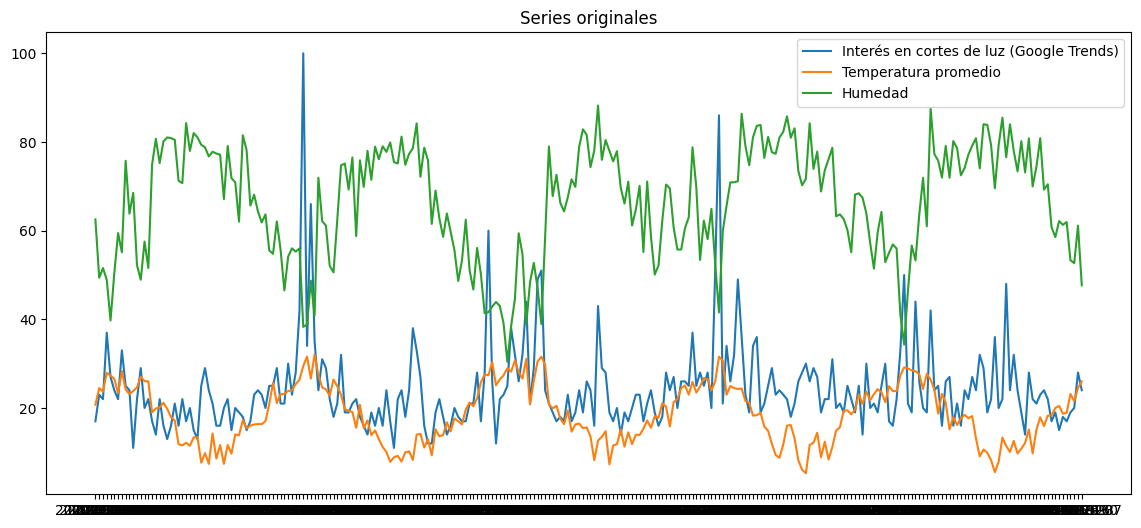

In [3]:
plt.figure(figsize=(14, 6))
plt.plot(df['Cortes'], label='Interés en cortes de luz (Google Trends)')
plt.plot(df['Temp'], label='Temperatura promedio')
plt.plot(df['Hum'], label='Humedad')
plt.title('Series originales')
plt.legend()
plt.show()

Visualización conjunta de las series temporales.
Este gráfico nos permite identificar visualmente posibles relaciones temporales entre las variables y detectar períodos de coincidencia entre picos de interés en cortes de luz y valores extremos de temperatura o humedad. También podemos observar la escala relativa de cada variable y su variabilidad temporal, así como realizar una primera inspección de la presencia de tendencias o patrones estacionales comunes.


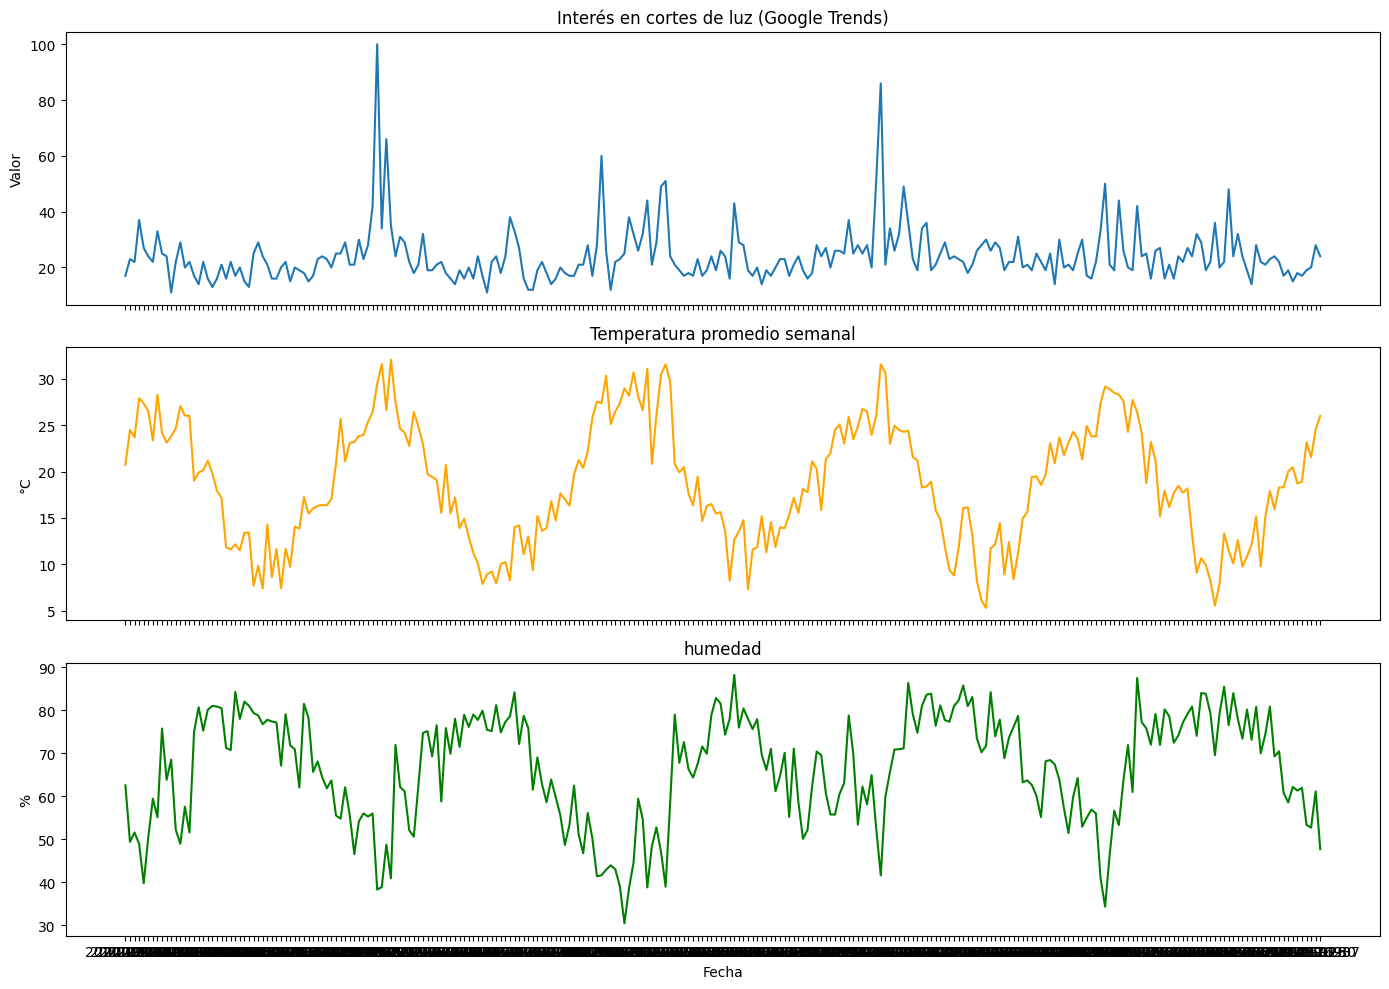

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df['Cortes'])
axes[0].set_title('Interés en cortes de luz (Google Trends)')
axes[0].set_ylabel('Valor')

axes[1].plot(df['Temp'], color='orange')
axes[1].set_title('Temperatura promedio semanal')
axes[1].set_ylabel('°C')

axes[2].plot(df['Hum'], color='green')
axes[2].set_title('humedad')
axes[2].set_ylabel('%')
axes[2].set_xlabel('Fecha')  # Solo en el último para no repetir

plt.tight_layout()
plt.show()


Esta visualización separada permite analizar en detalle la evolución temporal de cada variable sin la distorsión visual que puede generar la superposicion de escalas diferentes. Podemos identificar patrones específicos de cada serie, como ciclos estacionales, tendencias o episodios de alta variabilidad. Por ejemplo, la temperatura muestra una clara estacionalidad anual con valores más altos en verano y más bajos en invierno, mientras que la serie de cortes puede exhibir patrones más irregulares o episodios de alta variabilidad que requieren análisis adicional.

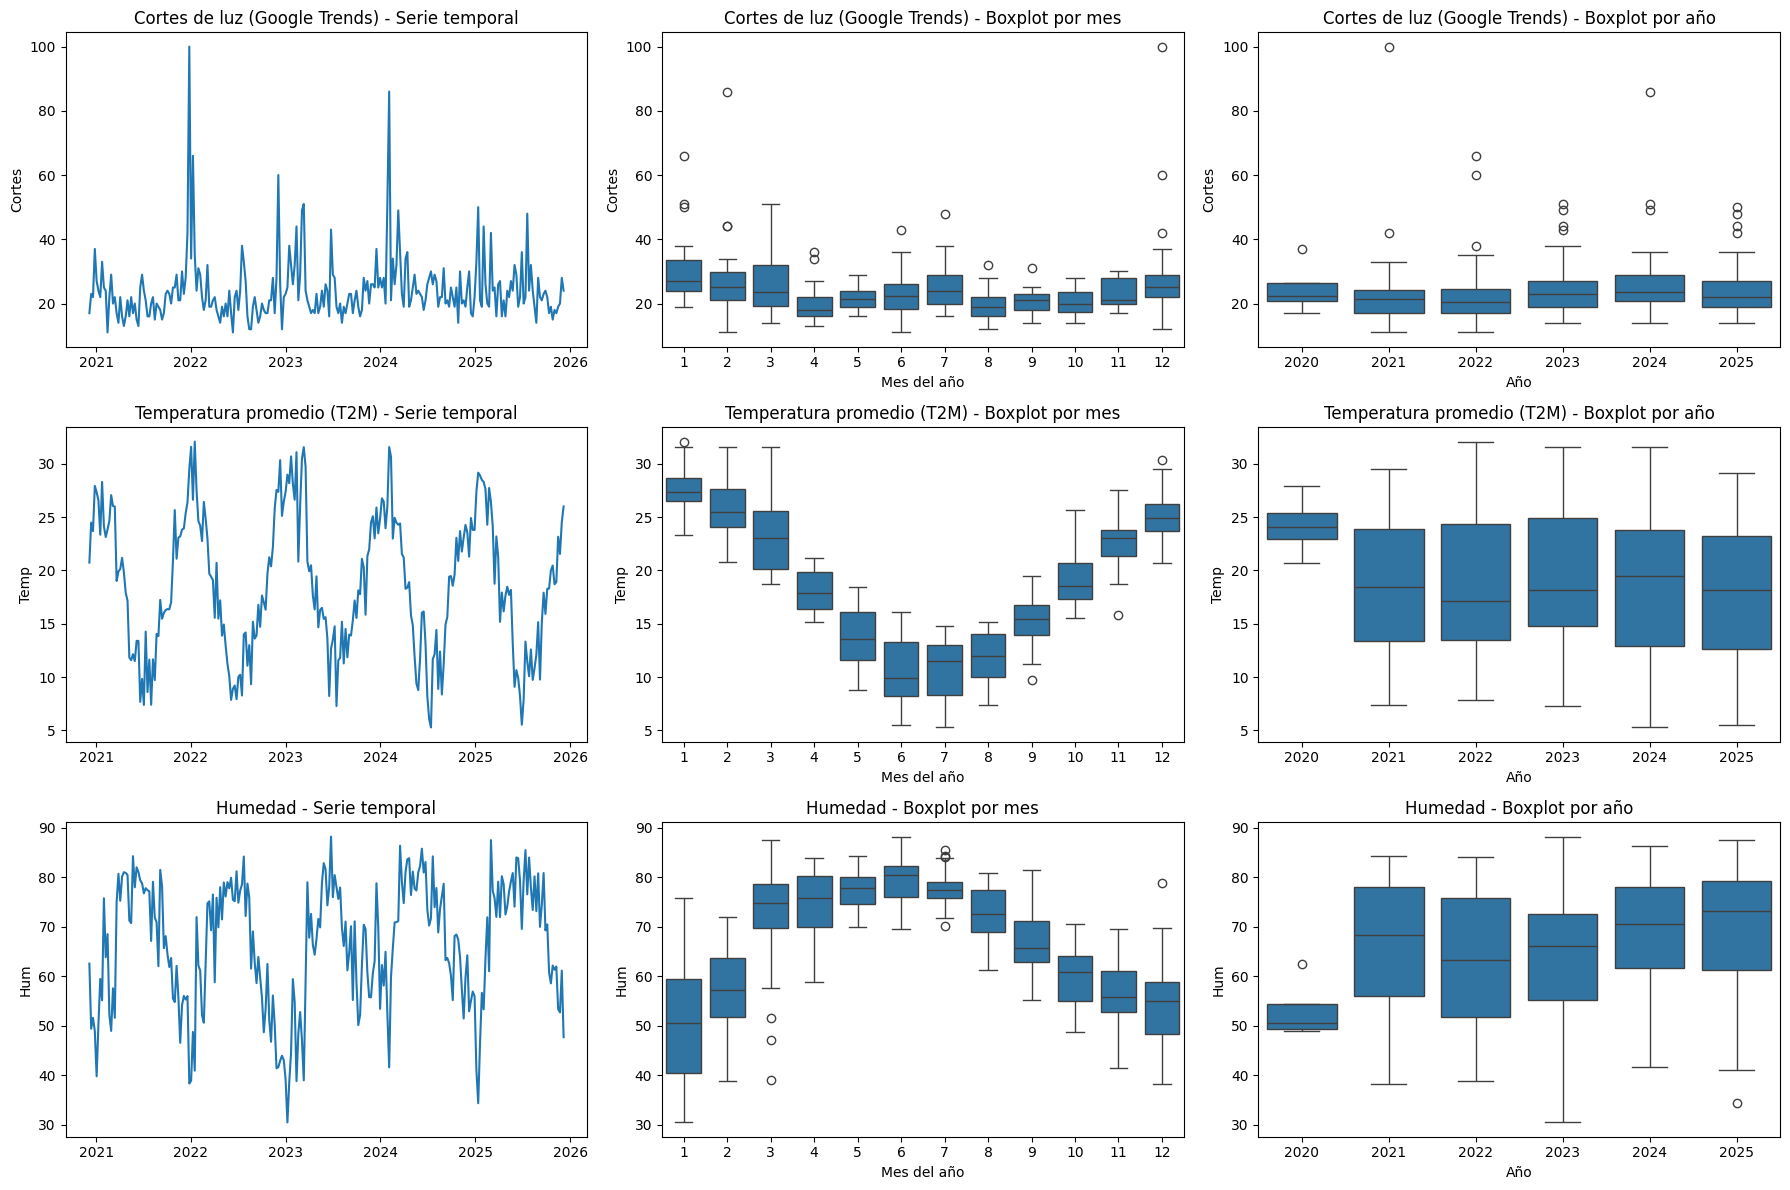

In [5]:
df.index = pd.to_datetime(df.index) # Convert index to DatetimeIndex
df['month'] = df.index.month
df['year'] = df.index.year

series = ['Cortes', 'Temp', 'Hum']
titulos = ['Cortes de luz (Google Trends)',
           'Temperatura promedio (T2M)',
           'Humedad']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for i, (col, titulo) in enumerate(zip(series, titulos)):

    # 1) Serie temporal
    axes[i, 0].plot(df.index, df[col])
    axes[i, 0].set_title(f"{titulo} - Serie temporal")
    axes[i, 0].set_ylabel(col)

    # 2) Boxplot por mes
    sns.boxplot(x=df['month'], y=df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f"{titulo} - Boxplot por mes")
    axes[i, 1].set_xlabel("Mes del año")

    # 3) Boxplot por año
    sns.boxplot(x=df['year'], y=df[col], ax=axes[i, 2])
    axes[i, 2].set_title(f"{titulo} - Boxplot por año")
    axes[i, 2].set_xlabel("Año")

plt.tight_layout()
plt.show()

Esta matriz de gráficos permite visualizar la evolución completa de cada variable a lo largo del tiempo.
La columna izquierda contiene las series temporales completas; la columna central presenta un boxplot de los valores por mes del año, lo que permite identificar patrones estacionales anuales, meses con mayor variabilidad o valores extremos, y evaluar si existe una estacionalidad sistemática en cada variable.

Por último, la columna derecha muestra el boxplot por año, permitiendo detectar cambios interanuales en los niveles promedio o en la variabilidad de cada serie, identificar tendencias de largo plazo y evaluar si existen años con comportamientos atípicos.

Análisis de autocorrelación y espectro (FAC, FACP, FAS)
El siguiente código genera, para cada una de las tres series, un conjunto de tres gráficos que caracterizan su estructura de dependencia temporal.
1. **FAC (Función de Autocorrelación)**: Muestra la correlación entre la serie y sus valores rezagados
2. **FACP (Función de Autocorrelación Parcial)**: Muestra la correlación parcial entre la serie y sus valores rezagados, controlando por los rezagos intermedios
3. **FAS (Función de Densidad Espectral / Periodograma)**: Muestra la distribución de la varianza de la serie en el dominio de frecuencias

**Objetivos**:
- **FAC**: Identificar la memoria temporal de la serie, detectar patrones de persistencia, y evaluar si la serie tiene dependencia de corto o largo plazo. También permite identificar estacionalidad mediante picos en rezagos múltiplos del período estacional (por ejemplo, rezago 52 para datos semanales con estacionalidad anual)
- **FACP**: Determinar el orden de un modelo autorregresivo (AR), ya que los rezagos significativos en la FACP sugieren qué términos AR incluir en el modelo. Es especialmente útil para identificar la estructura de dependencia de corto plazo
- **FAS**: Identificar componentes periódicos dominantes en la serie, detectar frecuencias asociadas a ciclos estacionales, y evaluar si la serie está dominada por componentes de alta o baja frecuencia

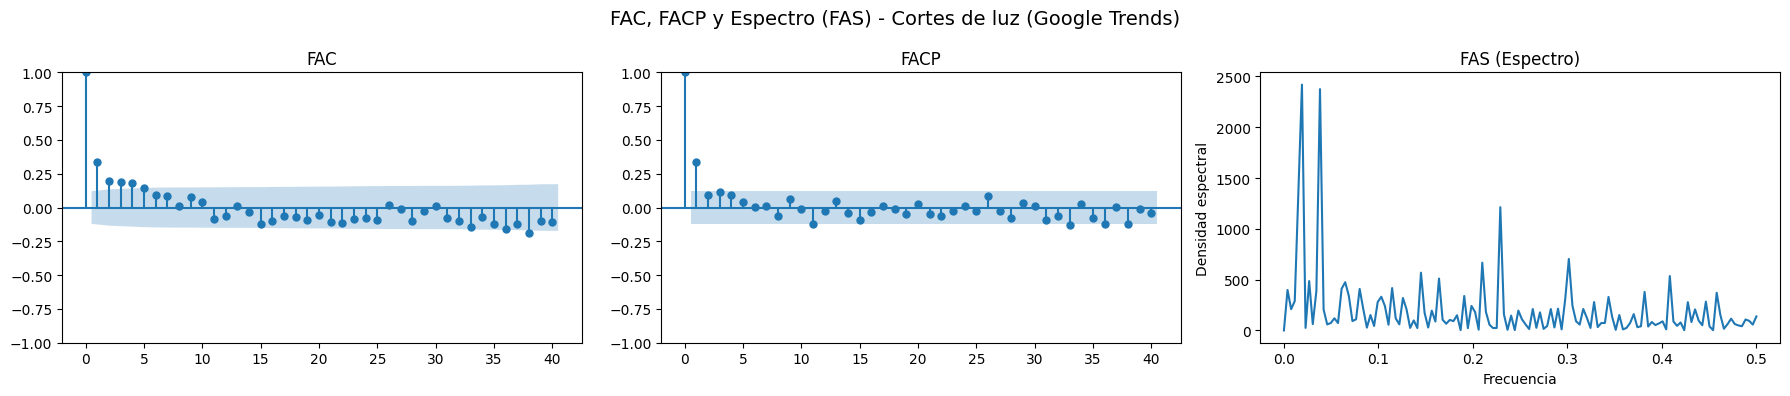

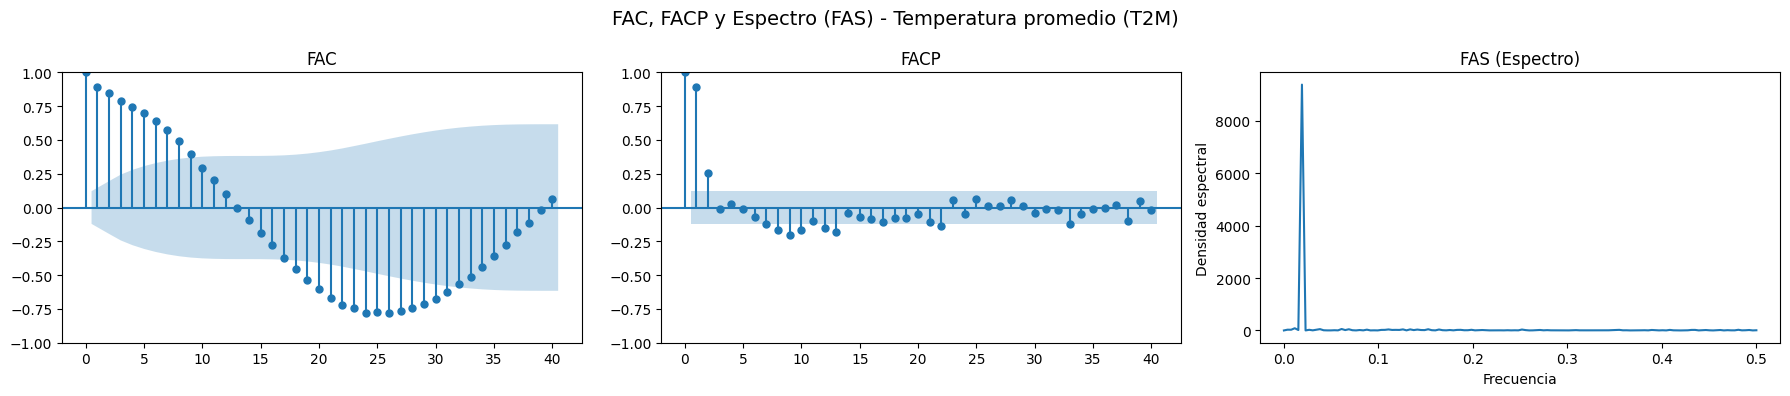

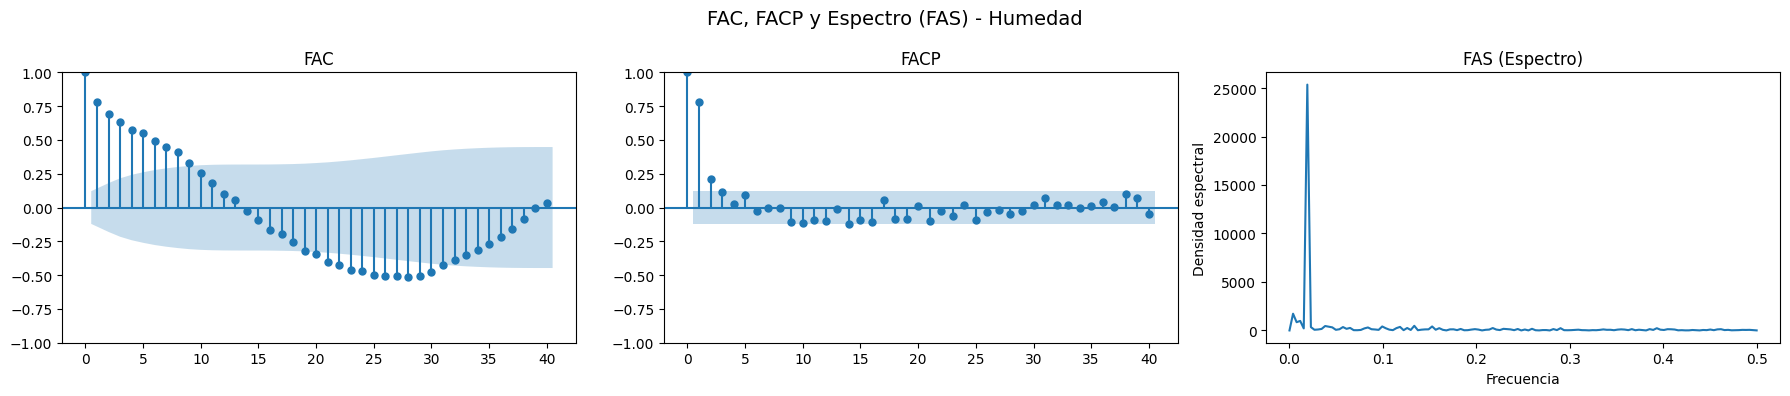

In [6]:
series = ['Cortes', 'Temp', 'Hum']
titulos = ['Cortes de luz (Google Trends)',
           'Temperatura promedio (T2M)',
           'Humedad']

for col, titulo in zip(series, titulos):

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"FAC, FACP y Espectro (FAS) - {titulo}", fontsize=14)

    # ------------------ 1) FAC ------------------
    plot_acf(df[col].dropna(), ax=axes[0], lags=40)
    axes[0].set_title("FAC")

    # ------------------ 2) FACP ------------------
    plot_pacf(df[col].dropna(), ax=axes[1], lags=40, method='ywm')
    axes[1].set_title("FACP")

    # ------------------ 3) FAS (Espectro) ------------------
    freq, psd = periodogram(df[col].dropna())
    axes[2].plot(freq, psd)
    axes[2].set_title("FAS (Espectro)")
    axes[2].set_xlabel("Frecuencia")
    axes[2].set_ylabel("Densidad espectral")

    plt.tight_layout()
    plt.show()

**Para la serie de Cortes**: En la FAC se observa una autocorrelación positiva y significativa en los primeros rezagos,
seguida por un decaimiento gradual hacia valores cercanos a cero. Este comportamiento
indica la presencia de dependencia temporal de corto plazo. La FACP muestra un pico
significativo en el primer rezago y valores no significativos para los rezagos posteriores. Este
patrón podría asociarse a un proceso autorregresivo de orden bajo, como un AR(1). La
ausencia de rezagos significativos posteriores refuerza la idea de que la dependencia
temporal es de corto plazo. Por su parte la FAS presenta picos en frecuencias bajas y no se
observan picos predominantes asociados a una frecuencia temporal específica, lo que da
indicios de que la estacionalidad anual no está muy marcada.

**Para la serie de Temperatura**: En la FAC se observa un patrón oscilante claramente definido, con autocorrelaciones
positivas en los primeros rezagos que luego se vuelven negativas y vuelven a acercarse a cero
en rezagos más largos. Este comportamiento sinusoidal es característico de series con fuerte
estacionalidad. La persistencia de autocorrelaciones significativas a lo largo de numerosos
rezagos indica que la serie podría no ser estacionaria en niveles y presenta una dependencia
temporal de largo plazo asociada al ciclo anual. La FACP muestra picos significativos en los
primeros rezagos, seguidos de valores cercanos a cero en rezagos posteriores. Este patrón
sugiere que, una vez controlada la estacionalidad, la dependencia de corto plazo puede
describirse mediante un componente autorregresivo de bajo orden. La ausencia de picos
relevantes en rezagos más altos refuerza la idea de que la estructura dinámica principal de la
serie está dominada por la estacionalidad más que por una compleja dinámica
autorregresiva. Por su parte, la FAS exhibe un pico pronunciado en una frecuencia baja bien
definida, lo que confirma la presencia de un componente periódico dominante.

**Para la serie de Humedad**: En la FAC se observa una autocorrelación positiva elevada en los primeros rezagos, seguida
de un decaimiento gradual que se vuelve negativo y retorna lentamente hacia valores
cercanos a cero. Este patrón oscilante es indicativo de la presencia de un componente
estacional, aunque menos marcado que en el caso de la serie temperatura. La persistencia de
autocorrelaciones significativas en varios rezagos sugiere que la serie presenta dependencia
temporal de mediano plazo y no es estrictamente estacionaria en niveles. La FACP muestra
un pico significativo en el primer rezago y valores cercanos a cero en los rezagos posteriores.
Este comportamiento es compatible con un proceso autorregresivo de bajo orden. La FAS
exhibe un pico dominante en frecuencias bajas, lo que confirma la presencia de un
componente cíclico relevante.

## 4. Diagnóstico de estacionariedad

Con el objetivo de evaluar formalmente la estacionariedad de las series seleccionadas, se
aplican pruebas de raíces unitarias, las cuales permiten contrastar la hipótesis nula de no
estacionariedad frente a la alternativa de estacionariedad.

En este script se utiliza el test de Dickey–Fuller Aumentado (ADF), el cual extiende la
prueba original propuesta por Dickey y Fuller (1979) incorporando rezagos adicionales de la
variable dependiente con el fin de controlar la autocorrelación serial de los residuos.

In [7]:
def test_adf(serie, nombre):
    resultado = adfuller(serie.dropna())
    print(f"\n--- Test ADF para {nombre} ---")
    print(f"ADF Statistic: {resultado[0]}")
    print(f"p-value: {resultado[1]}")
    print("Conclusión:",
          "Estacionaria (rechazo H0)" if resultado[1] < 0.05 else "No estacionaria (no se rechaza H0)")

# --- 6. Testear estacionariedad de cada serie ---
test_adf(df['Cortes'], 'Google Trends cortes')
test_adf(df['Temp'], 'Temperatura promedio')
test_adf(df['Hum'], 'Humedad')


--- Test ADF para Google Trends cortes ---
ADF Statistic: -6.642319582400187
p-value: 5.37130683459251e-09
Conclusión: Estacionaria (rechazo H0)

--- Test ADF para Temperatura promedio ---
ADF Statistic: -7.023876324182791
p-value: 6.438838984933922e-10
Conclusión: Estacionaria (rechazo H0)

--- Test ADF para Humedad ---
ADF Statistic: -4.987932331457902
p-value: 2.3446538124048328e-05
Conclusión: Estacionaria (rechazo H0)


Los resultados del test ADF aplicado a la serie correspondiente a las búsquedas de Google
Trends arrojan un estadístico de prueba de −6,64, con un p-valor significativamente inferior
al nivel de significación del 5%. En consecuencia, se rechaza la hipótesis nula de presencia de
raíz unitaria, concluyendo que la serie es estacionaria en niveles.

En el caso de la temperatura promedio, el test ADF arroja un estadístico de −7.02 y un
p-valor prácticamente nulo, lo que permite rechazar con holgura la hipótesis nula de no
estacionariedad. A pesar de presentar un patrón estacional marcado, la evidencia estadística
indica que la serie es estacionaria.

Por su parte, la serie de humedad promedio presenta un estadístico ADF de −4.99, con un
p-valor inferior a los niveles de significancia convencionales. En consecuencia, también se
rechaza la hipótesis nula de raíz unitaria, concluyendo que la serie es estacionaria

El test de Ljung-Box evalúa si una serie temporal es ruido blanco (sin autocorrelación). La hipótesis nula (H₀) es que la serie es ruido blanco; si se rechaza, hay evidencia de dependencia temporal.

In [8]:
from statsmodels.stats.diagnostic import acorr_ljungbox

series = ['Cortes', 'Temp', 'Hum']

for col in series:
    print(f"\n=== Test de Ljung–Box para {col} ===")

    # Testeamos en varios lags típicos
    result = acorr_ljungbox(df[col], lags=[10, 20, 30], return_df=True)
    print(result)

    # Interpretación automática básica
    for lag, p in zip(result.index, result['lb_pvalue']):
        if p < 0.05:
            print(f" → Lag {lag}: Rechazamos H0 → La serie NO es ruido blanco.")
        else:
            print(f" → Lag {lag}: No se rechaza H0 → La serie podría comportarse como ruido blanco.")



=== Test de Ljung–Box para Cortes ===
       lb_stat     lb_pvalue
10   69.833913  4.773506e-11
20   86.242585  3.339379e-10
30  102.480442  7.504505e-10
 → Lag 10: Rechazamos H0 → La serie NO es ruido blanco.
 → Lag 20: Rechazamos H0 → La serie NO es ruido blanco.
 → Lag 30: Rechazamos H0 → La serie NO es ruido blanco.

=== Test de Ljung–Box para Temp ===
        lb_stat      lb_pvalue
10  1182.473863  8.686429e-248
20  1512.691920  7.534187e-309
30  3105.155752   0.000000e+00
 → Lag 10: Rechazamos H0 → La serie NO es ruido blanco.
 → Lag 20: Rechazamos H0 → La serie NO es ruido blanco.
 → Lag 30: Rechazamos H0 → La serie NO es ruido blanco.

=== Test de Ljung–Box para Hum ===
        lb_stat      lb_pvalue
10   779.164506  6.212025e-161
20   893.686604  1.733286e-176
30  1568.196578  1.145599e-311
 → Lag 10: Rechazamos H0 → La serie NO es ruido blanco.
 → Lag 20: Rechazamos H0 → La serie NO es ruido blanco.
 → Lag 30: Rechazamos H0 → La serie NO es ruido blanco.



Para las tres series (Cortes, Temp, Hum), se rechaza H₀ en todos los rezagos considerados (10, 20, 30), con p-valores muy pequeños (< 0.05).

Si bien los tests de Dickey–Fuller Aumentado permiten evaluar la presencia de raíces
unitarias no estacionales, estos contrastes no están diseñados para detectar raíces unitarias
asociadas a componentes estacionales. En series que presentan patrones periódicos
marcados, como las series meteorológicas analizadas, resulta necesario complementar el
análisis con pruebas específicas de raíces unitarias estacionales.
Con este objetivo, se emplea el test propuesto por Hylleberg, Engle, Granger y Yoo (1990),
conocido como test HEGY, el cual permite contrastar la presencia de raíces unitarias tanto no
estacionales como estacionales, distinguiendo entre distintos tipos de integración estacional.

In [9]:
def hegy_test(series, s=52):
    """
    HEGY test para raíces unitarias estacionales.
    series: pd.Series
    s: frecuencia estacional (52 para semanal)
    """
    y = series.dropna().values
    T = len(y)

    # Diferencia estacional completa
    dy = y[s:] - y[:-s]

    # Componentes HEGY
    y_1 = y[s-1:-1]                 # raíz no estacional
    y_2 = y[s-1:-1] + y[:-s]        # raíz estacional (simplificada)

    # Matriz de regresores
    X = np.column_stack([y_1, y_2])
    X = sm.add_constant(X)

    model = sm.OLS(dy, X).fit()

    print(model.summary())
    return model
hegy_test(df['Cortes'], s=52)
hegy_test(df['Temp'], s=52)
hegy_test(df['Hum'], s=52)


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.441
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                     81.65
Date:                Mon, 22 Dec 2025   Prob (F-statistic):           7.22e-27
Time:                        20:03:04   Log-Likelihood:                -783.19
No. Observations:                 210   AIC:                             1572.
Df Residuals:                     207   BIC:                             1582.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.0620      2.303      5.673      0.0

En los tres casos, el test arrojó valores p extremadamente bajos (p < 0.001), lo que implica un rechazo contundente de la hipótesis nula de la presencia de raíz unitaria. Por lo tanto, las tres series pueden considerarse estacionarias en el sentido débil sin necesidad de aplicar diferenciación adicional.

## 5. Estimación y selección de modelos SARIMA mediante búsqueda exhaustiva

Con el objetivo de identificar una especificación adecuada para la dinámica temporal de la serie Cortes, se adoptó un enfoque de búsqueda exhaustiva acotada (grid search) sobre modelos SARIMA. Esta estrategia permite evaluar de forma sistemática un conjunto amplio de combinaciones de órdenes autorregresivos y de medias móviles, tanto en su componente no estacional como estacional, reduciendo el sesgo asociado a la selección manual de modelos y garantizando la comparabilidad bajo criterios homogéneos.

La búsqueda se diseñó teniendo en cuenta los resultados del análisis exploratorio previo, en particular: (i) la ausencia de una tendencia determinística marcada, (ii) la presencia de estacionalidad anual asociada a la frecuencia semanal de la serie y (iii) una dependencia temporal de corto plazo sugerida por las funciones de autocorrelación y autocorrelación parcial.

In [10]:
# División train / test (80 / 20)
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size].copy()
test  = df.iloc[train_size:].copy()

y_train = train['Cortes'].asfreq('W').dropna()
y_test  = test['Cortes'].asfreq('W').dropna()

print(f"Train: {train.index[0]} → {train.index[-1]}")
print(f"Test:  {test.index[0]} → {test.index[-1]}")


Train: 2020-12-06 00:00:00 → 2024-12-01 00:00:00
Test:  2024-12-08 00:00:00 → 2025-12-07 00:00:00


### 5.1. Definición del espacio de búsqueda

#### 5.2 Serie objetivo : Cortes de luz

***Justificación del análisis con y sin diferenciación***

Los tests de estacionariedad aplicados sobre la serie en niveles sugieren que no es necesaria la diferenciación (d = 0, D = 0). Por consistencia teórica, se realiza primero una búsqueda exhaustiva restringida a ese caso. Sin embargo, dada la marcada regularidad anual observada en el análisis exploratorio, se evalúa adicionalmente un segundo espacio de modelos permitiendo diferenciación no estacional y/o estacional (d ∈ {0,1}, D ∈ {0,1}), con el objetivo de capturar patrones persistentes que no siempre son absorbidos por los términos AR/MA.
Debido a que la diferenciación transforma la serie y modifica la verosimilitud, los criterios AIC/BIC se utilizan para seleccionar modelos dentro de cada espacio, y la comparación final entre candidatos se traslada a desempeño predictivo fuera de muestra (MAE/MAPE).

El espacio de modelos evaluado se definió de manera deliberadamente acotada, priorizando la parsimonia y la estabilidad de estimación, pero lo suficientemente amplio como para capturar estructuras dinámicas relevantes. En particular, se consideraron:

Órdenes no estacionales:

p,q∈{0,1,2,3}

Órdenes estacionales:

P,Q∈{0,1,2}

Periodicidad estacional fija:

s=52

La estimación se realizó bajo dos escenarios complementarios:

- Modelos sin diferenciación, fijando d=0 y D=0.

- Modelos con diferenciación, permitiendo diferenciación no estacional y/o estacional cuando resulta necesaria para estabilizar la serie.

En todos los casos se incluyó un término constante y se desactivaron las restricciones estrictas de estacionariedad e invertibilidad durante la estimación, con el fin de evitar descartar soluciones potencialmente válidas por dificultades numéricas en el proceso de optimización.

In [20]:
#### BÚSQUEDA EXHAUSTIVA DE MODELOS SARIMA (SIN DIFERENCIACIÓN)

import itertools

# 1) Serie objetivo
y_train = train['Cortes'].copy()
print(f"y_train inicial: {len(y_train)} observaciones")
print(f"NaN en y_train: {y_train.isna().sum()}")

y_train = y_train.dropna()
print(f"y_train después de dropna: {len(y_train)} observaciones")

if len(y_train) == 0:
    print("ERROR: y_train está vacío!")
else:
    print(f"✓ y_train tiene {len(y_train)} observaciones")
    print(f"  Rango: {y_train.min()} - {y_train.max()}")
    
    # 2) Definir rangos para la búsqueda (d=0 y D=0 fijos)
    p_range = range(0, 4)  # 0, 1, 2, 3
    d = 0  # SIN diferenciación no estacional
    q_range = range(0, 4)  # 0, 1, 2, 3
    
    P_range = range(0, 3)  # 0, 1, 2
    D = 0  # SIN diferenciación estacional
    Q_range = range(0, 3)  # 0, 1, 2
    s = 52  # Estacionalidad semanal (52 semanas)
    
    # Generar todas las combinaciones
    models_to_test = []
    for p in p_range:
        for q in q_range:
            for P in P_range:
                for Q in Q_range:
                    order = (p, d, q)
                    seasonal_order = (P, D, Q, s)
                    models_to_test.append((order, seasonal_order))
    
    print(f"\n📊 Total de modelos a probar: {len(models_to_test)}")
    print(f"   p: {list(p_range)}")
    print(f"   d: {d} (fijo)")
    print(f"   q: {list(q_range)}")
    print(f"   P: {list(P_range)}")
    print(f"   D: {D} (fijo)")
    print(f"   Q: {list(Q_range)}")
    print(f"   s: {s}")
    
    # 3) Ajustar todos los modelos
    results_list = []
    
    print("\n" + "="*80)
    print("Ajustando modelos SARIMA...")
    print("="*80)
    
    for i, (order, seasonal_order) in enumerate(models_to_test, 1):
        model_name = f"SARIMA{order}x{seasonal_order}"
        
        # Mostrar progreso cada 10 modelos
        if i % 10 == 0 or i == 1:
            print(f"\n[{i}/{len(models_to_test)}] Procesando...")
        
        try:
            model = SARIMAX(
                y_train,
                order=order,
                seasonal_order=seasonal_order,
                trend="c",
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            fitted = model.fit(disp=False, maxiter=200, method='lbfgs')
            
            results_list.append({
                "Modelo": model_name,
                "p": order[0],
                "d": order[1],
                "q": order[2],
                "P": seasonal_order[0],
                "D": seasonal_order[1],
                "Q": seasonal_order[2],
                "AIC": fitted.aic,
                "BIC": fitted.bic,
                "LogLik": fitted.llf,
                "Convergio": bool(getattr(fitted, "mle_retvals", {}).get("converged", True))
            })
            
            print(f"✓ {model_name} | AIC={fitted.aic:.2f} | BIC={fitted.bic:.2f}")
            
        except Exception as e:
            results_list.append({
                "Modelo": model_name,
                "p": order[0],
                "d": order[1],
                "q": order[2],
                "P": seasonal_order[0],
                "D": seasonal_order[1],
                "Q": seasonal_order[2],
                "AIC": np.nan,
                "BIC": np.nan,
                "LogLik": np.nan,
                "Convergio": False,
                "Error": str(e)[:120]
            })
            # Solo mostrar errores si no son muy comunes
            if "singular" not in str(e).lower():
                print(f"✗ {model_name} | Error: {str(e)[:60]}")
    
    # 4) Crear DataFrame con resultados
    df_models = pd.DataFrame(results_list)
    
    # Filtrar solo modelos que convergieron
    df_converged = df_models[df_models['Convergio'] == True].copy()
    
    print("\n" + "="*80)
    print(f"RESUMEN DE RESULTADOS")
    print("="*80)
    print(f"Total modelos probados: {len(df_models)}")
    print(f"Modelos que convergieron: {len(df_converged)}")
    print(f"Modelos con errores: {len(df_models) - len(df_converged)}")
    
    if len(df_converged) > 0:
        # Ordenar por AIC
        df_aic = df_converged.sort_values("AIC").reset_index(drop=True)
        
        print("\n" + "="*80)
        print("TOP 10 MODELOS POR AIC")
        print("="*80)
        print(df_aic[["Modelo","AIC","BIC","LogLik","Convergio"]].head(10).to_string(index=False))
        
        # Ordenar por BIC
        df_bic = df_converged.sort_values("BIC").reset_index(drop=True)
        
        print("\n" + "="*80)
        print("TOP 10 MODELOS POR BIC")
        print("="*80)
        print(df_bic[["Modelo","AIC","BIC","LogLik","Convergio"]].head(10).to_string(index=False))
        
        # Mejor modelo
        best_model = df_aic.iloc[0]
        print("\n" + "="*80)
        print("🏆 MEJOR MODELO (menor AIC)")
        print("="*80)
        print(f"Modelo: {best_model['Modelo']}")
        print(f"AIC: {best_model['AIC']:.2f}")
        print(f"BIC: {best_model['BIC']:.2f}")
        print(f"Log-Likelihood: {best_model['LogLik']:.2f}")
    else:
        print("\n⚠️ ADVERTENCIA: Ningún modelo convergió correctamente")
        print("Mostrando errores más comunes:")
        if 'Error' in df_models.columns:
            error_counts = df_models['Error'].value_counts().head(5)
            print(error_counts)


y_train inicial: 209 observaciones
NaN en y_train: 0
y_train después de dropna: 209 observaciones
✓ y_train tiene 209 observaciones
  Rango: 11 - 100

📊 Total de modelos a probar: 144
   p: [0, 1, 2, 3]
   d: 0 (fijo)
   q: [0, 1, 2, 3]
   P: [0, 1, 2]
   D: 0 (fijo)
   Q: [0, 1, 2]
   s: 52

Ajustando modelos SARIMA...

[1/144] Procesando...
✓ SARIMA(0, 0, 0)x(0, 0, 0, 52) | AIC=1575.43 | BIC=1582.10
✓ SARIMA(0, 0, 0)x(0, 0, 1, 52) | AIC=1213.52 | BIC=1222.67
✓ SARIMA(0, 0, 0)x(0, 0, 2, 52) | AIC=774.34 | BIC=784.91
✓ SARIMA(0, 0, 0)x(1, 0, 0, 52) | AIC=1216.11 | BIC=1225.28
✓ SARIMA(0, 0, 0)x(1, 0, 1, 52) | AIC=1199.06 | BIC=1211.26
✓ SARIMA(0, 0, 0)x(1, 0, 2, 52) | AIC=775.83 | BIC=789.06
✓ SARIMA(0, 0, 0)x(2, 0, 0, 52) | AIC=792.28 | BIC=802.89
✓ SARIMA(0, 0, 0)x(2, 0, 1, 52) | AIC=793.44 | BIC=806.71
✓ SARIMA(0, 0, 0)x(2, 0, 2, 52) | AIC=776.03 | BIC=791.90

[10/144] Procesando...
✓ SARIMA(0, 0, 1)x(0, 0, 0, 52) | AIC=1546.92 | BIC=1556.92
✓ SARIMA(0, 0, 1)x(0, 0, 1, 52) | AIC=119

In [21]:
#### BÚSQUEDA EXHAUSTIVA DE MODELOS SARIMA (CON DIFERENCIACIÓN)

# 1) Serie objetivo
y_train = train['Cortes'].copy()
print(f"y_train inicial: {len(y_train)} observaciones")
print(f"NaN en y_train: {y_train.isna().sum()}")

y_train = y_train.dropna()
print(f"y_train después de dropna: {len(y_train)} observaciones")

if len(y_train) == 0:
    raise ValueError("ERROR: y_train está vacío!")
else:
    print(f"✓ y_train tiene {len(y_train)} observaciones")
    print(f"  Rango: {y_train.min()} - {y_train.max()}")

# 2) Definir rangos para la búsqueda (d y D ahora SÍ varían)
p_range = range(0, 4)  # 0, 1, 2, 3
q_range = range(0, 4)  # 0, 1, 2, 3

P_range = range(0, 3)  # 0, 1, 2
Q_range = range(0, 3)  # 0, 1, 2

d_values = [0, 1]      # diferenciación no estacional
D_values = [0, 1]      # diferenciación estacional

s = 52  # Estacionalidad semanal (52 semanas)

# Generar todas las combinaciones
models_to_test = []
for p in p_range:
    for q in q_range:
        for P in P_range:
            for Q in Q_range:
                for d in d_values:
                    for D in D_values:
                        order = (p, d, q)
                        seasonal_order = (P, D, Q, s)
                        models_to_test.append((order, seasonal_order))

print(f"\n📊 Total de modelos a probar: {len(models_to_test)}")
print(f"   p: {list(p_range)}")
print(f"   d: {d_values}")
print(f"   q: {list(q_range)}")
print(f"   P: {list(P_range)}")
print(f"   D: {D_values}")
print(f"   Q: {list(Q_range)}")
print(f"   s: {s}")

# 3) Ajustar todos los modelos
results_list = []

print("\n" + "="*80)
print("Ajustando modelos SARIMA (con diferenciación)...")
print("="*80)

for i, (order, seasonal_order) in enumerate(models_to_test, 1):
    model_name = f"SARIMA{order}x{seasonal_order}"

    # Mostrar progreso cada 10 modelos
    if i % 10 == 0 or i == 1:
        print(f"\n[{i}/{len(models_to_test)}] Procesando...")

    try:
        model = SARIMAX(
            y_train,
            order=order,
            seasonal_order=seasonal_order,
            trend="c",
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        fitted = model.fit(disp=False, maxiter=200, method='lbfgs')

        results_list.append({
            "Modelo": model_name,
            "p": order[0],
            "d": order[1],
            "q": order[2],
            "P": seasonal_order[0],
            "D": seasonal_order[1],
            "Q": seasonal_order[2],
            "AIC": fitted.aic,
            "BIC": fitted.bic,
            "LogLik": fitted.llf,
            "Convergio": bool(getattr(fitted, "mle_retvals", {}).get("converged", True))
        })

        print(f"✓ {model_name} | AIC={fitted.aic:.2f} | BIC={fitted.bic:.2f}")

    except Exception as e:
        results_list.append({
            "Modelo": model_name,
            "p": order[0],
            "d": order[1],
            "q": order[2],
            "P": seasonal_order[0],
            "D": seasonal_order[1],
            "Q": seasonal_order[2],
            "AIC": np.nan,
            "BIC": np.nan,
            "LogLik": np.nan,
            "Convergio": False,
            "Error": str(e)[:120]
        })

        # Solo mostrar errores si no son muy comunes
        if "singular" not in str(e).lower():
            print(f"✗ {model_name} | Error: {str(e)[:60]}")

# 4) Crear DataFrame con resultados
df_models_diff = pd.DataFrame(results_list)

# Filtrar solo modelos que convergieron
df_converged_diff = df_models_diff[df_models_diff['Convergio'] == True].copy()

print("\n" + "="*80)
print("RESUMEN DE RESULTADOS (CON DIFERENCIACIÓN)")
print("="*80)
print(f"Total modelos probados: {len(df_models_diff)}")
print(f"Modelos que convergieron: {len(df_converged_diff)}")
print(f"Modelos con errores: {len(df_models_diff) - len(df_converged_diff)}")

if len(df_converged_diff) > 0:
    # Ordenar por AIC
    df_aic_diff = df_converged_diff.sort_values("AIC").reset_index(drop=True)

    print("\n" + "="*80)
    print("TOP 10 MODELOS POR AIC (CON DIFERENCIACIÓN)")
    print("="*80)
    print(df_aic_diff[["Modelo","AIC","BIC","LogLik","Convergio"]].head(10).to_string(index=False))

    # Ordenar por BIC
    df_bic_diff = df_converged_diff.sort_values("BIC").reset_index(drop=True)

    print("\n" + "="*80)
    print("TOP 10 MODELOS POR BIC (CON DIFERENCIACIÓN)")
    print("="*80)
    print(df_bic_diff[["Modelo","AIC","BIC","LogLik","Convergio"]].head(10).to_string(index=False))

    # Mejor modelo
    best_model_diff = df_aic_diff.iloc[0]
    print("\n" + "="*80)
    print("🏆 MEJOR MODELO (menor AIC) — CON DIFERENCIACIÓN")
    print("="*80)
    print(f"Modelo: {best_model_diff['Modelo']}")
    print(f"AIC: {best_model_diff['AIC']:.2f}")
    print(f"BIC: {best_model_diff['BIC']:.2f}")
    print(f"Log-Likelihood: {best_model_diff['LogLik']:.2f}")
else:
    print("\n⚠️ ADVERTENCIA: Ningún modelo convergió correctamente")
    print("Mostrando errores más comunes:")
    if 'Error' in df_models_diff.columns:
        error_counts = df_models_diff['Error'].value_counts().head(5)
        print(error_counts)


y_train inicial: 209 observaciones
NaN en y_train: 0
y_train después de dropna: 209 observaciones
✓ y_train tiene 209 observaciones
  Rango: 11 - 100

📊 Total de modelos a probar: 576
   p: [0, 1, 2, 3]
   d: [0, 1]
   q: [0, 1, 2, 3]
   P: [0, 1, 2]
   D: [0, 1]
   Q: [0, 1, 2]
   s: 52

Ajustando modelos SARIMA (con diferenciación)...

[1/576] Procesando...
✓ SARIMA(0, 0, 0)x(0, 0, 0, 52) | AIC=1575.43 | BIC=1582.10
✓ SARIMA(0, 0, 0)x(0, 1, 0, 52) | AIC=1271.15 | BIC=1277.25
✓ SARIMA(0, 1, 0)x(0, 0, 0, 52) | AIC=1615.60 | BIC=1622.26
✓ SARIMA(0, 1, 0)x(0, 1, 0, 52) | AIC=1325.85 | BIC=1331.94
✓ SARIMA(0, 0, 0)x(0, 0, 1, 52) | AIC=1213.52 | BIC=1222.67
✓ SARIMA(0, 0, 0)x(0, 1, 1, 52) | AIC=4620.94 | BIC=4628.87
✓ SARIMA(0, 1, 0)x(0, 0, 1, 52) | AIC=5620.61 | BIC=5629.74
✓ SARIMA(0, 1, 0)x(0, 1, 1, 52) | AIC=844.65 | BIC=852.55
✓ SARIMA(0, 0, 0)x(0, 0, 2, 52) | AIC=774.34 | BIC=784.91

[10/576] Procesando...
✓ SARIMA(0, 0, 0)x(0, 1, 2, 52) | AIC=409.87 | BIC=417.67
✓ SARIMA(0, 1, 0)x(0

### Evaluación preliminar fuera de muestra.
Dado que los criterios de información no son estrictamente comparables entre modelos con distinto grado de diferenciación, la comparación entre los modelos candidatos se traslada a su desempeño predictivo fuera de muestra. En esta etapa se evalúan métricas de error (MAE, RMSE y MAPE) sobre el conjunto de test, con el objetivo de obtener evidencia empírica adicional para la selección final del modelo.Dado que los modelos con diferenciación estacional (D=1) presentan una mejora sustancial respecto de aquellos sin dicha componente, se restringió la búsqueda a modelos parsimoniosos con D=1 y órdenes bajos, evitando el sobreajuste.

In [12]:
from pmdarima import auto_arima
print("Iniciando búsqueda de parámetros con AutoARIMA...")
model_auto = auto_arima(
    y_train, 
    seasonal=True, 
    m=52, 
    stepwise=True, 
    suppress_warnings=True, 
    trace=True
)
print(model_auto.summary())


Iniciando búsqueda de parámetros con AutoARIMA...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[52] intercept   : AIC=1557.509, Time=3.80 sec
 ARIMA(0,0,0)(0,0,0)[52] intercept   : AIC=1582.456, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[52] intercept   : AIC=1553.667, Time=1.23 sec
 ARIMA(0,0,1)(0,0,1)[52] intercept   : AIC=1559.850, Time=0.86 sec
 ARIMA(0,0,0)(0,0,0)[52]             : AIC=1964.231, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[52] intercept   : AIC=1553.239, Time=0.03 sec
 ARIMA(1,0,0)(0,0,1)[52] intercept   : AIC=1553.693, Time=0.84 sec
 ARIMA(1,0,0)(1,0,1)[52] intercept   : AIC=1555.657, Time=2.46 sec
 ARIMA(2,0,0)(0,0,0)[52] intercept   : AIC=1552.487, Time=0.04 sec
 ARIMA(2,0,0)(1,0,0)[52] intercept   : AIC=1553.263, Time=1.75 sec
 ARIMA(2,0,0)(0,0,1)[52] intercept   : AIC=1553.306, Time=1.14 sec
 ARIMA(2,0,0)(1,0,1)[52] intercept   : AIC=inf, Time=2.83 sec
 ARIMA(3,0,0)(0,0,0)[52] intercept   : AIC=1552.894, Time=0.10 sec
 ARIMA(2,0,1)(0,0,0)[52] intercept   : AI

In [11]:
# Candidatos (uno por cada espacio)
candidate_no_diff = {
    "order": (1, 0, 3),
    "seasonal_order": (0, 0, 2, 52),
    "name": "SARIMA(1,0,3)x(0,0,2,52)"
}

# Asumido provisionalmente 
candidate_diff = {
    "order": (2, 1, 3),
    "seasonal_order": (0, 1, 2, 52),
    "name": "SARIMA(2,1,3)x(0,1,2,52)"
}

candidate_auto = {
    "name": "AutoARIMA(1,0,1)(0,0,0)",
    "order": (1, 0, 1),
    "seasonal_order": (0, 0, 0, 52)
}



In [14]:
#función para fit + forecast + métricas en test (MAE, RMSE, MAPE)
def eval_sarima(train_series, test_series, order, seasonal_order, name="", maxiter=200):
    model = SARIMAX(
        train_series,
        order=order,
        seasonal_order=seasonal_order,
        trend="c",
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    fitted = model.fit(disp=False, maxiter=maxiter, method="lbfgs")

    # Forecast exactamente del tamaño del test
    fc = fitted.get_forecast(steps=len(test_series)).predicted_mean
    fc.index = test_series.index  # alinear índices

    # Métricas
    err = test_series - fc
    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err**2))

    # MAPE (evitar división por cero)
    denom = np.where(test_series.values == 0, np.nan, test_series.values)
    mape = np.nanmean(np.abs(err.values / denom)) * 100

    return {
        "Modelo": name,
        "order": order,
        "seasonal_order": seasonal_order,
        "AIC_in": fitted.aic,
        "BIC_in": fitted.bic,
        "MAE_test": mae,
        "RMSE_test": rmse,
        "MAPE_test": mape,
        "fit": fitted,
        "forecast": fc
    }


In [15]:
#evaluar ambos candidatos
res_no = eval_sarima(
    y_train, y_test,
    order=candidate_no_diff["order"],
    seasonal_order=candidate_no_diff["seasonal_order"],
    name=candidate_no_diff["name"]
)

res_diff = eval_sarima(
    y_train, y_test,
    order=candidate_diff["order"],
    seasonal_order=candidate_diff["seasonal_order"],
    name=candidate_diff["name"]
)

res_auto = eval_sarima(
    y_train, y_test,
    order=candidate_auto["order"],
    seasonal_order=candidate_auto["seasonal_order"],
    name=candidate_auto["name"]
)


df_compare = pd.DataFrame([
    {k: v for k, v in res_no.items() if k not in ["fit", "forecast"]},
    {k: v for k, v in res_diff.items() if k not in ["fit", "forecast"]},
    {k: v for k, v in res_auto.items() if k not in ["fit", "forecast"]}
])

df_compare


,Modelo,order,seasonal_order,AIC_in,BIC_in,MAE_test,RMSE_test,MAPE_test
0,"SARIMA(1,0,3)x(0,0,2,52)","(1, 0, 3)","(0, 0, 2, 52)",748.768113,769.689077,6.036910,7.797344,26.165788
1,"SARIMA(2,1,3)x(0,1,2,52)","(2, 1, 3)","(0, 1, 2, 52)",382.156582,398.997391,9.031436,12.345378,40.351797
2,"AutoARIMA(1,0,1)(0,0,0)","(1, 0, 1)","(0, 0, 0, 52)",1536.976158,1550.307033,5.692224,7.919898,23.492896


Con el objetivo de comparar modelos candidatos provenientes de espacios de búsqueda no directamente comparables mediante criterios de información, se evaluó su desempeño predictivo fuera de muestra sobre el conjunto de test, utilizando las métricas MAE, RMSE y MAPE.

Los resultados muestran diferencias claras y consistentes en términos de capacidad predictiva. El modelo SARIMA(1,0,3)×(0,0,2)[52], estimado sin diferenciación, presenta errores sustancialmente menores en todas las métricas consideradas. En contraste, el modelo con diferenciación SARIMA(2,1,3)×(0,1,2)[52] exhibe un deterioro marcado del desempeño fuera de muestra, con incrementos significativos en MAE, RMSE y MAPE. En particular, el aumento del RMSE y del MAPE sugiere una menor capacidad del modelo diferenciado para reproducir tanto la magnitud como la variabilidad observada de la serie durante el período de test.

En este contexto, la evidencia empírica indica que la incorporación de diferenciación no mejora —y en este caso perjudica— el desempeño predictivo fuera de muestra. No obstante, ambos modelos se conservan para las etapas posteriores del análisis, en tanto representan especificaciones alternativas que permiten analizar el trade-off entre ajuste estadístico, estabilidad del modelo y capacidad predictiva bajo distintos supuestos estructurales.

### Significancia de los parámetros

Se realiza un análisis de significancia de parámetros que permite verificar si estos son estadísticamente distintos de cero, es decir, si aportan información al modelo o si su efecto no justifica su incorporación.

In [16]:
model_no = SARIMAX(
    y_train,
    order=(1,0,3),
    seasonal_order=(0,0,2,52),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

model_diff = SARIMAX(
    y_train,
    order=(2,1,3),
    seasonal_order=(0,1,2,52),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

model_auto = SARIMAX(
    y_train,
    order=(1,0,1),
    seasonal_order=(0,0,0,52),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

In [17]:
model_no.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                        SARIMAX Results                                        
===============================================================================================
Dep. Variable:                                  Cortes   No. Observations:                  209
Model:             SARIMAX(1, 0, 3)x(0, 0, [1, 2], 52)   Log Likelihood                -366.384
Date:                                 Mon, 22 Dec 2025   AIC                            748.768
Time:                                         20:09:51   BIC                            769.689
Sample:                                     12-06-2020   HQIC                           757.238
                                          - 12-01-2024                                         
Covariance Type:                                   opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      5.6106      6.597      0.850      0.395      -7.319      18.540
ar.L1          0.7812      0.252      3.105      0.002       0.288       1.274
ma.L1         -0.4955      0.261     -1.895      0.058      -1.008       0.017
ma.L2         -0.2229      0.142     -1.565      0.118      -0.502       0.056
ma.L3          0.1663      0.084      1.983      0.047       0.002       0.331
ma.S.L52       0.0382     50.477      0.001      0.999     -98.895      98.972
ma.S.L104      0.0401   1494.270   2.68e-05      1.000   -2928.675    2928.755
sigma2        82.3047   9516.291      0.009      0.993   -1.86e+04    1.87e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):               460.81
Prob(Q):                              0.93   Prob(JB):                         0.00
Heteroskedasticity (H):               0.32   Skew:                             2.22
Prob(H) (two-sided):                  0.00   Kurtosis:                        12.47
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [18]:
model_diff.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                        SARIMAX Results                                        
===============================================================================================
Dep. Variable:                                  Cortes   No. Observations:                  209
Model:             SARIMAX(2, 1, 3)x(0, 1, [1, 2], 52)   Log Likelihood                -182.078
Date:                                 Mon, 22 Dec 2025   AIC                            382.157
Time:                                         20:09:51   BIC                            398.997
Sample:                                     12-06-2020   HQIC                           388.521
                                          - 12-01-2024                                         
Covariance Type:                                   opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0644      0.320      0.202      0.840      -0.562       0.691
ar.L1         -0.1967      0.119     -1.652      0.099      -0.430       0.037
ar.L2         -0.8008      0.144     -5.572      0.000      -1.083      -0.519
ma.L1         -0.9341    178.403     -0.005      0.996    -350.597     348.729
ma.L2          0.9340   2539.076      0.000      1.000   -4975.564    4977.432
ma.L3         -1.0000   2633.226     -0.000      1.000   -5162.029    5160.028
ma.S.L52      -0.0456     28.204     -0.002      0.999     -55.325      55.234
ma.S.L104      0.0158    642.162   2.45e-05      1.000   -1258.598    1258.629
sigma2       110.9562   2.92e+05      0.000      1.000   -5.73e+05    5.73e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.83   Jarque-Bera (JB):               319.83
Prob(Q):                              0.36   Prob(JB):                         0.00
Heteroskedasticity (H):               0.13   Skew:                             2.54
Prob(H) (two-sided):                  0.00   Kurtosis:                        14.58
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [19]:
model_auto.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                 Cortes   No. Observations:                  209
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -764.488
Date:                Mon, 22 Dec 2025   AIC                           1536.976
Time:                        20:09:51   BIC                           1550.307
Sample:                    12-06-2020   HQIC                          1542.367
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      6.0368      2.719      2.221      0.026       0.708      11.365
ar.L1          0.7512      0.102      7.334      0.000       0.550       0.952
ma.L1         -0.4630      0.123     -3.775      0.000      -0.703      -0.223
sigma2        94.3787      4.542     20.777      0.000      85.476     103.282
===================================================================================
Ljung-Box (L1) (Q):                   0.10   Jarque-Bera (JB):              2916.97
Prob(Q):                              0.76   Prob(JB):                         0.00
Heteroskedasticity (H):               0.78   Skew:                             3.17
Prob(H) (two-sided):                  0.29   Kurtosis:                        20.27
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

El Modelo 3 (SARIMA(1,0,1)) es el más adecuado desde la perspectiva de significancia de parámetros:
Todos los parámetros son significativos, errores estándar razonables, sin heterocedasticidad, modelo parsimonioso y bien identificado.

El Modelo 1 tiene problemas con los componentes estacionales MA, sugiriendo sobreparametrización estacional.

El Modelo 2 presenta problemas graves de identificación, especialmente en los términos MA, indicando sobreparametrización.

#### Autoarima para series climáticas

Con el objetivo de incorporar las variables meteorológicas al análisis multivariado, se realizó previamente un ajuste univariado de las series de temperatura y humedad. En base al análisis exploratorio y a los resultados obtenidos en las secciones anteriores, en particular, los diagnósticos de estacionariedad, autocorrelación y comportamiento estacional, se optó por una estrategia de modelización simplificada para estas variables.

En este marco, se empleó el procedimiento automático AutoARIMA para la identificación y estimación de modelos adecuados para las series de temperatura y humedad, permitiendo seleccionar de manera sistemática los órdenes autorregresivos y de medias móviles que mejor se ajustan a cada caso según criterios de información. Esta elección responde a un criterio práctico y parsimonioso, dado que el interés central del trabajo se concentra en la dinámica de la serie objetivo asociada a los cortes de luz, mientras que las variables meteorológicas cumplen un rol explicativo y de soporte dentro del enfoque VAR.

***Temperatura***

In [20]:
# División train / test (80 / 20)
train_size_temp = int(len(df) * 0.8)
train_temp = df.iloc[:train_size_temp].copy()
test_temp  = df.iloc[train_size_temp:].copy()

y_train_temp = train_temp['Temp'].asfreq('W').dropna()
y_test_temp  = test_temp['Temp'].asfreq('W').dropna()

print(f"Train: {train_temp.index[0]} → {train_temp.index[-1]}")
print(f"Test:  {test_temp.index[0]} → {test_temp.index[-1]}")

Train: 2020-12-06 00:00:00 → 2024-12-01 00:00:00
Test:  2024-12-08 00:00:00 → 2025-12-07 00:00:00


In [21]:
from pmdarima import auto_arima
print("Iniciando búsqueda de parámetros con AutoARIMA...")
model_auto_temp = auto_arima(
    y_train_temp, 
    seasonal=True, 
    m=52, 
    stepwise=True, 
    suppress_warnings=True, 
    trace=True
)
print(model_auto_temp.summary())

Iniciando búsqueda de parámetros con AutoARIMA...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[52] intercept   : AIC=inf, Time=4.06 sec
 ARIMA(0,0,0)(0,0,0)[52] intercept   : AIC=1377.088, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[52] intercept   : AIC=1049.214, Time=2.18 sec
 ARIMA(0,0,1)(0,0,1)[52] intercept   : AIC=1195.543, Time=0.94 sec
 ARIMA(0,0,0)(0,0,0)[52]             : AIC=1843.644, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[52] intercept   : AIC=1048.696, Time=0.03 sec
 ARIMA(1,0,0)(0,0,1)[52] intercept   : AIC=1049.648, Time=0.58 sec
 ARIMA(1,0,0)(1,0,1)[52] intercept   : AIC=inf, Time=3.08 sec
 ARIMA(2,0,0)(0,0,0)[52] intercept   : AIC=1033.817, Time=0.05 sec
 ARIMA(2,0,0)(1,0,0)[52] intercept   : AIC=1032.240, Time=2.30 sec
 ARIMA(2,0,0)(2,0,0)[52] intercept   : AIC=1028.029, Time=8.98 sec
 ARIMA(2,0,0)(2,0,1)[52] intercept   : AIC=1029.317, Time=29.07 sec
 ARIMA(2,0,0)(1,0,1)[52] intercept   : AIC=inf, Time=2.64 sec
 ARIMA(1,0,0)(2,0,0)[52] intercept   : AIC=inf, Ti

In [22]:
candidate_auto_temp = {
    "name": "AutoARIMA(2,0,0)(2,0,0)",
    "order": (2, 0, 0),
    "seasonal_order": (2, 0, 0, 52)
}
res_auto_temp = eval_sarima(
    y_train_temp, y_test_temp,
    order=candidate_auto_temp["order"],
    seasonal_order=candidate_auto_temp["seasonal_order"],
    name=candidate_auto_temp["name"]
)
df_compare_temp = pd.DataFrame([
    {k: v for k, v in res_auto_temp.items() if k not in ["fit", "forecast"]}
])

df_compare_temp

,Modelo,order,seasonal_order,AIC_in,BIC_in,MAE_test,RMSE_test,MAPE_test
0,"AutoARIMA(2,0,0)(2,0,0)","(2, 0, 0)","(2, 0, 0, 52)",514.556139,530.364512,2.507246,3.164179,19.55371


In [23]:
model_auto_temp = SARIMAX(
    y_train_temp,
    order=(2,0,0),
    seasonal_order=(2,0,0,52),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

model_auto_temp.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                               Temp   No. Observations:                  209
Model:             SARIMAX(2, 0, 0)x(2, 0, 0, 52)   Log Likelihood                -251.278
Date:                            Mon, 22 Dec 2025   AIC                            514.556
Time:                                    20:12:33   BIC                            530.365
Sample:                                12-06-2020   HQIC                           520.959
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.1924      0.888      2.470      0.014       0.452       3.932
ar.L1          0.5090      0.094      5.426      0.000       0.325       0.693
ar.L2         -0.0151      0.094     -0.161      0.872      -0.199       0.169
ar.S.L52       0.2796      0.093      3.021      0.003       0.098       0.461
ar.S.L104      0.5107      0.091      5.603      0.000       0.332       0.689
sigma2         7.7007      1.054      7.303      0.000       5.634       9.767
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 0.16
Prob(Q):                              0.94   Prob(JB):                         0.92
Heteroskedasticity (H):               0.80   Skew:                            -0.08
Prob(H) (two-sided):                  0.52   Kurtosis:                         3.10
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

***Humedad***

In [24]:
# División train / test (80 / 20)
train_size_hum = int(len(df) * 0.8)
train_hum = df.iloc[:train_size_hum].copy()
test_hum  = df.iloc[train_size_hum:].copy()

y_train_hum = train_hum['Hum'].asfreq('W').dropna()
y_test_hum  = test_hum['Hum'].asfreq('W').dropna()

print(f"Train: {train_hum.index[0]} → {train_hum.index[-1]}")
print(f"Test:  {test_hum.index[0]} → {test_hum.index[-1]}")

Train: 2020-12-06 00:00:00 → 2024-12-01 00:00:00
Test:  2024-12-08 00:00:00 → 2025-12-07 00:00:00


In [25]:
from pmdarima import auto_arima
print("Iniciando búsqueda de parámetros con AutoARIMA...")
model_auto_hum = auto_arima(
    y_train_hum, 
    seasonal=True, 
    m=52, 
    stepwise=True, 
    suppress_warnings=True, 
    trace=True
)
print(model_auto_hum.summary())

Iniciando búsqueda de parámetros con AutoARIMA...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[52] intercept   : AIC=inf, Time=6.41 sec
 ARIMA(0,0,0)(0,0,0)[52] intercept   : AIC=1657.064, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[52] intercept   : AIC=1461.612, Time=2.96 sec
 ARIMA(0,0,1)(0,0,1)[52] intercept   : AIC=1535.200, Time=0.99 sec
 ARIMA(0,0,0)(0,0,0)[52]             : AIC=2353.083, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[52] intercept   : AIC=1460.641, Time=0.03 sec
 ARIMA(1,0,0)(0,0,1)[52] intercept   : AIC=1461.955, Time=1.26 sec
 ARIMA(1,0,0)(1,0,1)[52] intercept   : AIC=inf, Time=3.58 sec
 ARIMA(2,0,0)(0,0,0)[52] intercept   : AIC=1455.298, Time=0.06 sec
 ARIMA(2,0,0)(1,0,0)[52] intercept   : AIC=1455.630, Time=4.10 sec
 ARIMA(2,0,0)(0,0,1)[52] intercept   : AIC=1456.163, Time=1.40 sec
 ARIMA(2,0,0)(1,0,1)[52] intercept   : AIC=inf, Time=4.15 sec
 ARIMA(3,0,0)(0,0,0)[52] intercept   : AIC=1454.840, Time=0.11 sec
 ARIMA(3,0,0)(1,0,0)[52] intercept   : AIC=1455.348

In [26]:
candidate_auto_hum = {
    "name": "AutoARIMA(1,0,2)(2,0,0)",
    "order": (1, 0, 2),
    "seasonal_order": (2, 0, 0, 52)
}
res_auto_hum = eval_sarima(
    y_train_hum, y_test_hum,
    order=candidate_auto_hum["order"],
    seasonal_order=candidate_auto_hum["seasonal_order"],
    name=candidate_auto_hum["name"]
)
df_compare_hum = pd.DataFrame([
    {k: v for k, v in res_auto_hum.items() if k not in ["fit", "forecast"]}
])

df_compare_hum

,Modelo,order,seasonal_order,AIC_in,BIC_in,MAE_test,RMSE_test,MAPE_test
0,"AutoARIMA(1,0,2)(2,0,0)","(1, 0, 2)","(2, 0, 0, 52)",701.264396,719.775133,7.382575,9.203547,12.364315


In [27]:
model_auto_hum = SARIMAX(
    y_train_hum,
    order=(1,0,2),
    seasonal_order=(2,0,0,52),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

model_auto_hum.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                 Hum   No. Observations:                  209
Model:             SARIMAX(1, 0, 2)x(2, 0, [], 52)   Log Likelihood                -343.633
Date:                             Mon, 22 Dec 2025   AIC                            701.265
Time:                                     20:21:20   BIC                            719.776
Sample:                                 12-06-2020   HQIC                           708.764
                                      - 12-01-2024                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.8203      0.766      2.378      0.017       0.320       3.321
ar.L1          0.9434      0.017     56.768      0.000       0.911       0.976
ma.L1         -0.5563      2.793     -0.199      0.842      -6.030       4.917
ma.L2         -0.4429      1.260     -0.351      0.725      -2.913       2.028
ar.S.L52       0.1724      0.088      1.961      0.050    7.76e-05       0.345
ar.S.L104      0.4239      0.087      4.851      0.000       0.253       0.595
sigma2        40.3137    112.662      0.358      0.720    -180.499     261.126
===================================================================================
Ljung-Box (L1) (Q):                   0.31   Jarque-Bera (JB):                 2.13
Prob(Q):                              0.58   Prob(JB):                         0.34
Heteroskedasticity (H):               0.63   Skew:                            -0.34
Prob(H) (two-sided):                  0.18   Kurtosis:                         3.19
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## 6. Validación y diagnóstico de los modelos candidatos

En esta sección se analizan los dos modelos candidatos identificados en el Punto 5, con el objetivo de evaluar su adecuación estadística mediante el análisis de residuos y pruebas de diagnóstico.


Para cada modelo:

Media aproximadamente cero

Ausencia de autocorrelación

Varianza estable

Distribución razonable (no perfecta)

# Gráficos de residuos

In [29]:
def residual_diagnostics(model, title):
    resid = model.resid

    fig, ax = plt.subplots(1, 3, figsize=(15,4))
    ax[0].plot(resid)
    ax[0].set_title(f"{title} – Residuos")

    ax[1].hist(resid, bins=20)
    ax[1].set_title("Histograma")

    plot_acf(resid, lags=52, ax=ax[2])
    ax[2].set_title("FAC de residuos")

    plt.tight_layout()
    plt.show()


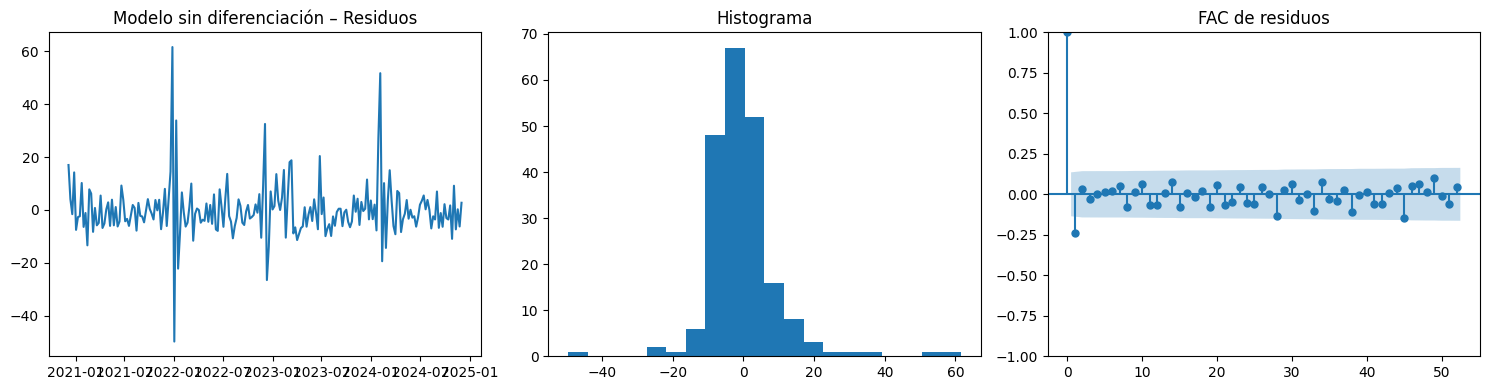

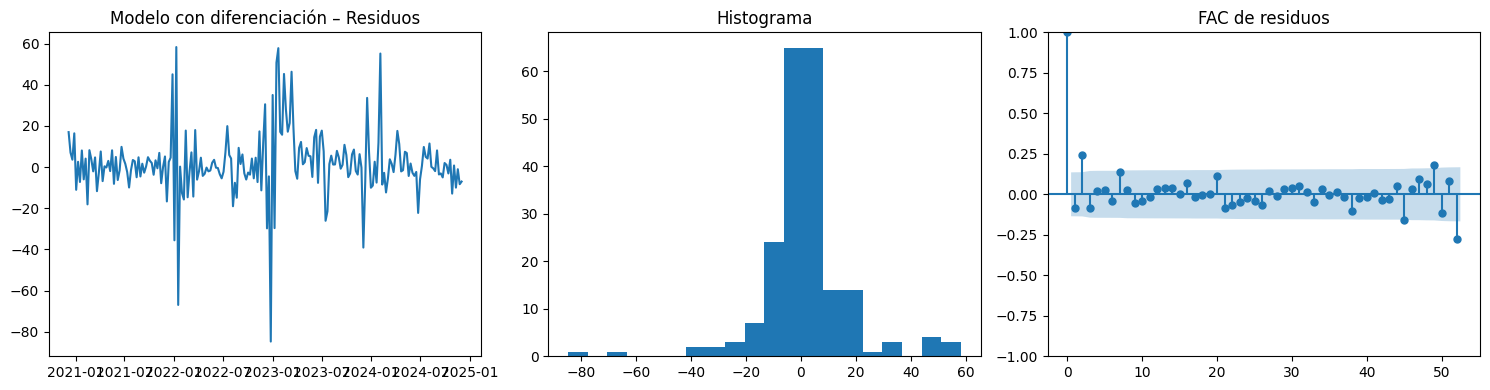

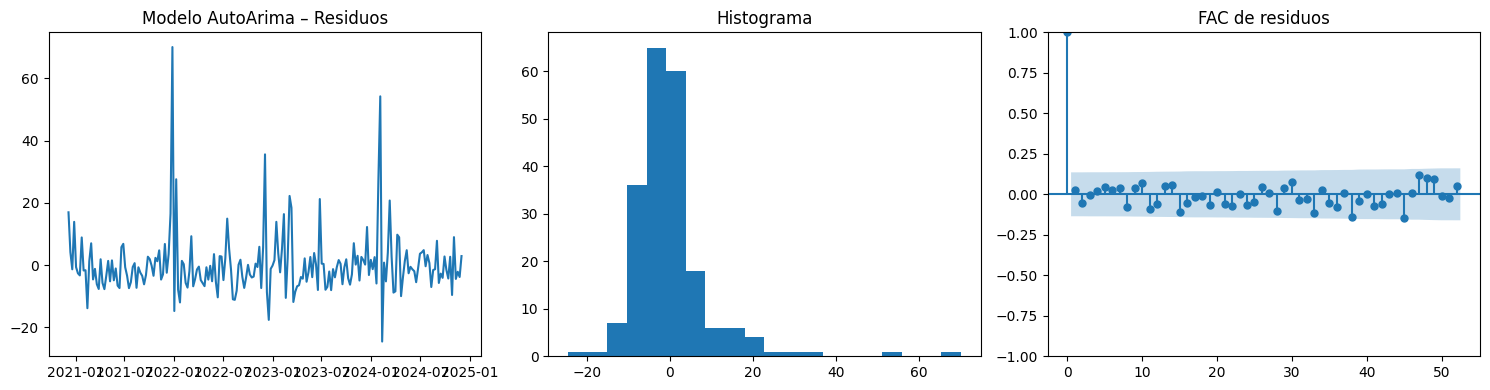

In [ ]:
# Cortes
residual_diagnostics(model_no, "Modelo sin diferenciación")
residual_diagnostics(model_diff, "Modelo con diferenciación")
residual_diagnostics(model_auto, "Modelo AutoArima")


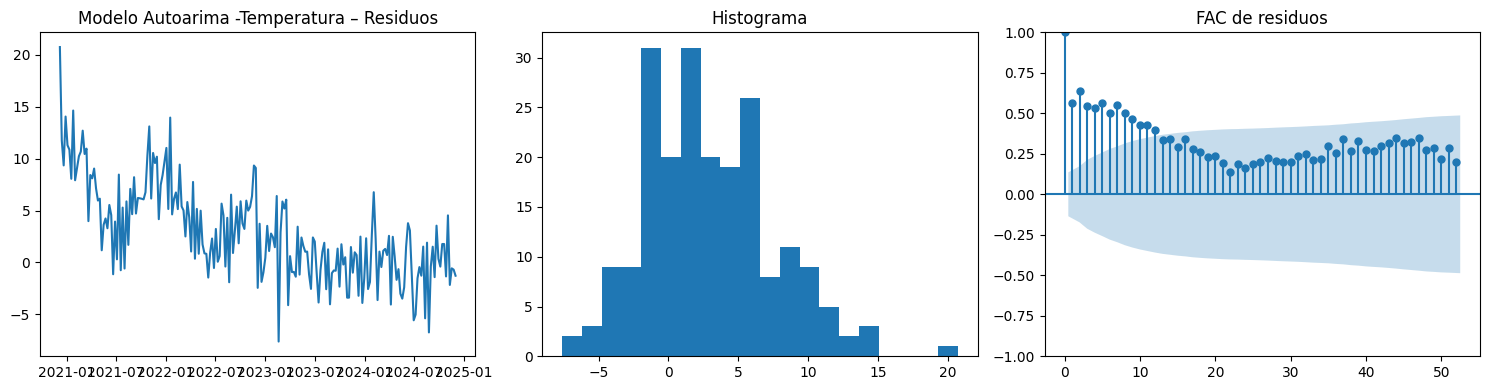

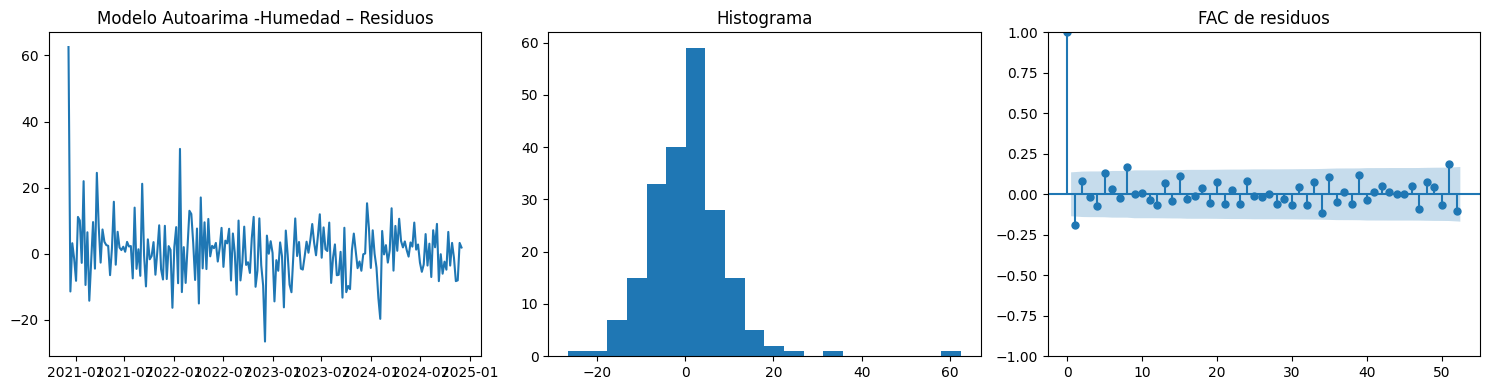

In [31]:
# Humedad y Temperatura
residual_diagnostics(model_auto_temp, "Modelo Autoarima -Temperatura")
residual_diagnostics(model_auto_hum, "Modelo Autoarima -Humedad")

### 6.4 Test de Ljung–Box

In [32]:
from statsmodels.stats.diagnostic import acorr_ljungbox


In [33]:
def ljung_box_test(model, lags=20):
    resid = model.resid
    lb = acorr_ljungbox(resid, lags=[lags], return_df=True)
    return lb


In [ ]:
#Cortes
lb_no = ljung_box_test(model_no)
lb_diff = ljung_box_test(model_diff)
lb_auto = ljung_box_test(model_auto)
lb_no, lb_diff, lb_auto


(      lb_stat  lb_pvalue
 20  22.054875    0.33754,
       lb_stat  lb_pvalue
 20  26.420056   0.152383,
       lb_stat  lb_pvalue
 20  12.600835   0.893846)

In [34]:
# Temperatura y humedad
lb_auto_temp = ljung_box_test(model_auto_temp)
lb_auto_hum = ljung_box_test(model_auto_hum)
lb_auto_temp, lb_auto_hum

(       lb_stat      lb_pvalue
 20  846.199868  2.175565e-166,
       lb_stat  lb_pvalue
 20  28.632801   0.095245)

In [35]:
from statsmodels.stats.stattools import jarque_bera

def normality_test_jb(model):
    resid = model.resid
    jb_stat, jb_pvalue, skew, kurt = jarque_bera(resid)
    
    return {
        "JB statistic": jb_stat,
        "p-value": jb_pvalue,
        "Skewness": skew,
        "Kurtosis": kurt
    }

In [ ]:
#Cortes
jb_no = normality_test_jb(model_no)
jb_diff = normality_test_jb(model_diff)
jb_auto = normality_test_jb(model_auto)
jb_no, jb_diff, jb_auto


({'JB statistic': np.float64(1213.4268175957475),
  'p-value': np.float64(3.2189517161269927e-264),
  'Skewness': np.float64(1.5165388304533405),
  'Kurtosis': np.float64(14.407949792951277)},
 {'JB statistic': np.float64(483.781218009354),
  'p-value': np.float64(8.876531223384418e-106),
  'Skewness': np.float64(-0.23495976626483664),
  'Kurtosis': np.float64(10.438615443116834)},
 {'JB statistic': np.float64(2775.51360145537),
  'p-value': np.float64(0.0),
  'Skewness': np.float64(3.1025394921508145),
  'Kurtosis': np.float64(19.73966128801513)})

In [36]:
# Temperatura y Humedad
jb_auto_temp = normality_test_jb(model_auto_temp)
jb_auto_hum = normality_test_jb(model_auto_hum)
jb_auto_temp, jb_auto_hum

({'JB statistic': np.float64(12.871099456251269),
  'p-value': np.float64(0.0016035269561927331),
  'Skewness': np.float64(0.5651328242321211),
  'Kurtosis': np.float64(3.4477952144599575)},
 {'JB statistic': np.float64(1032.1330401309024),
  'p-value': np.float64(7.501671468727241e-225),
  'Skewness': np.float64(1.6337464811573965),
  'Kurtosis': np.float64(13.384890182872525)})

### 6.5 Interpretación

El análisis de residuos muestra que ambos modelos candidatos presentan un comportamiento compatible, en términos generales, con los supuestos del modelo SARIMA. En el modelo sin diferenciación, los residuos se encuentran centrados en cero, sin evidencia de autocorrelación remanente, resultado que es confirmado por el test de Ljung–Box, el cual no permite rechazar la hipótesis nula de ausencia de autocorrelación.

En el caso del modelo con diferenciación, si bien los residuos exhiben una mayor variabilidad y episodios de valores extremos, el test de Ljung–Box tampoco detecta autocorrelación residual estadísticamente significativa. Esto sugiere que, desde el punto de vista del ajuste dinámico, la especificación logra capturar adecuadamente la dependencia temporal de la serie, aun cuando la estructura residual sea menos estable que en el modelo sin diferenciación.

No obstante, al contrastar estos resultados con la evaluación predictiva fuera de muestra, el modelo con diferenciación muestra un desempeño claramente inferior en términos de MAE, RMSE y MAPE. En este contexto, ambos modelos se mantienen en el análisis como especificaciones válidas desde el punto de vista estadístico, aunque con desempeños predictivos diferenciados, lo que refuerza el análisis comparativo y el estudio del trade-off entre estabilidad del ajuste y capacidad predictiva.

## 7. Validación y diagnóstico de los modelos candidatos

Con el objetivo de complementar la evaluación cuantitativa mediante métricas de error, se presenta una comparación gráfica entre los valores observados y los pronósticos fuera de muestra generados por cada modelo. Esta representación permite visualizar la capacidad de los modelos para capturar la dinámica de la serie en el período de test, así como posibles desviaciones sistemáticas.

### 7.1 Evaluación gráfica del desempeño fuera de muestra

***Cortes - Google Trends***

#### Modelo sin diferenciación

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [31]:
# Ajuste SOLO con train
model_no = SARIMAX(
    y_train,
    order=(1,0,3),
    seasonal_order=(0,0,2,52),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# Forecast sobre test
fc_no = model_no.get_forecast(steps=len(y_test)).predicted_mean
fc_no.index = y_test.index

# Métricas
rmse_no = np.sqrt(mean_squared_error(y_test, fc_no))
mae_no  = mean_absolute_error(y_test, fc_no)

print(f"SARIMA sin diferenciación | RMSE: {rmse_no:.2f} | MAE: {mae_no:.2f}")


SARIMA sin diferenciación | RMSE: 7.80 | MAE: 6.04


El error absoluto medio de 6.04 indica que, en promedio, las predicciones se desvían aproximadamente 6 unidades del valor observado. El RMSE ligeramente superior al MAE sugiere algunos errores grandes, aunque el modelo captura bien la dinámica fuera de muestra.

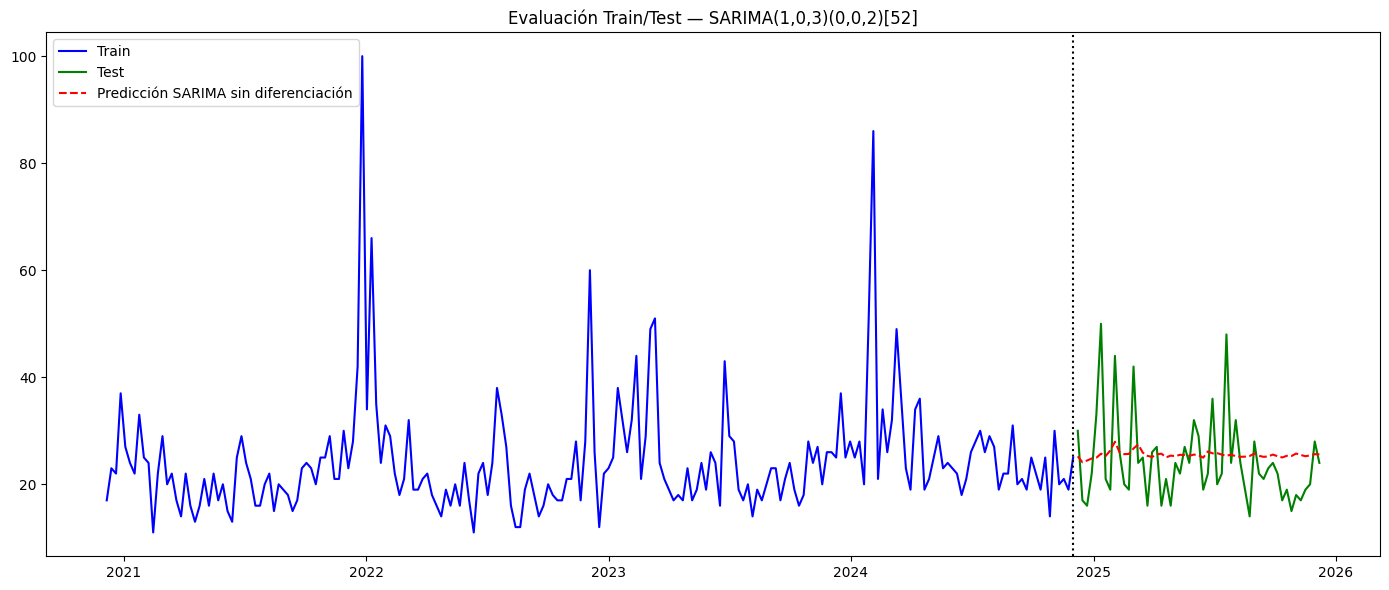

In [32]:
# Gráfico
plt.figure(figsize=(14,6))
plt.plot(y_train, label="Train", color="blue")
plt.plot(y_test, label="Test", color="green")
plt.plot(fc_no, label="Predicción SARIMA sin diferenciación",
         linestyle="--", color="red")

plt.axvline(y_train.index[-1], color="black", linestyle=":")
plt.title("Evaluación Train/Test — SARIMA(1,0,3)(0,0,2)[52]")
plt.legend()
plt.tight_layout()
plt.show()


#### Modelo con diferenciación

In [33]:
model_diff = SARIMAX(
    y_train,
    order=(2,1,3),
    seasonal_order=(0,1,2,52),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

fc_diff = model_diff.get_forecast(steps=len(y_test)).predicted_mean
fc_diff.index = y_test.index

rmse_diff = np.sqrt(mean_squared_error(y_test, fc_diff))
mae_diff  = mean_absolute_error(y_test, fc_diff)

print(f"SARIMA con diferenciación | RMSE: {rmse_diff:.2f} | MAE: {mae_diff:.2f}")


SARIMA con diferenciación | RMSE: 12.35 | MAE: 9.03


El RMSE de 12.35 y el MAE de 9.03 son mayores que en el modelo sin diferenciación. En promedio, las predicciones se desvían aproximadamente 9 unidades, un incremento del 49% en el error absoluto medio. La diferenciación no mejora la capacidad predictiva fuera de muestra.

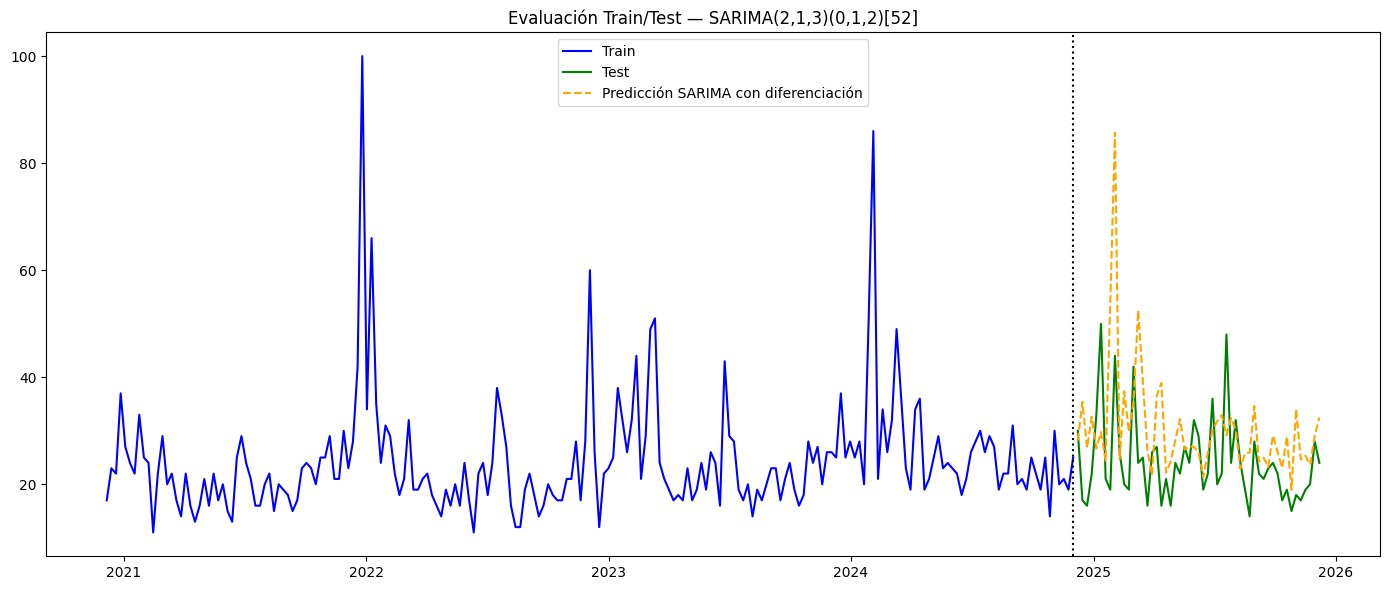

In [34]:
plt.figure(figsize=(14,6))
plt.plot(y_train, label="Train", color="blue")
plt.plot(y_test, label="Test", color="green")
plt.plot(fc_diff, label="Predicción SARIMA con diferenciación",
         linestyle="--", color="orange")

plt.axvline(y_train.index[-1], color="black", linestyle=":")
plt.title("Evaluación Train/Test — SARIMA(2,1,3)(0,1,2)[52]")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
model_auto = SARIMAX(
    y_train,
    order=(1,0,1),
    seasonal_order=(0,0,0,52),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

fc_auto = model_auto.get_forecast(steps=len(y_test)).predicted_mean
fc_auto.index = y_test.index

rmse_auto = np.sqrt(mean_squared_error(y_test, fc_auto))
mae_auto  = mean_absolute_error(y_test, fc_auto)

print(f"Autoarima | RMSE: {rmse_auto:.2f} | MAE: {mae_auto:.2f}")


SARIMA con diferenciación | RMSE: 7.92 | MAE: 5.69


Desempeño similar al Modelo 1, con el menor MAE (5.69). A pesar de ser el más simple (sin componente estacional), logra un balance entre simplicidad y capacidad predictiva, capturando la dinámica de corto plazo.

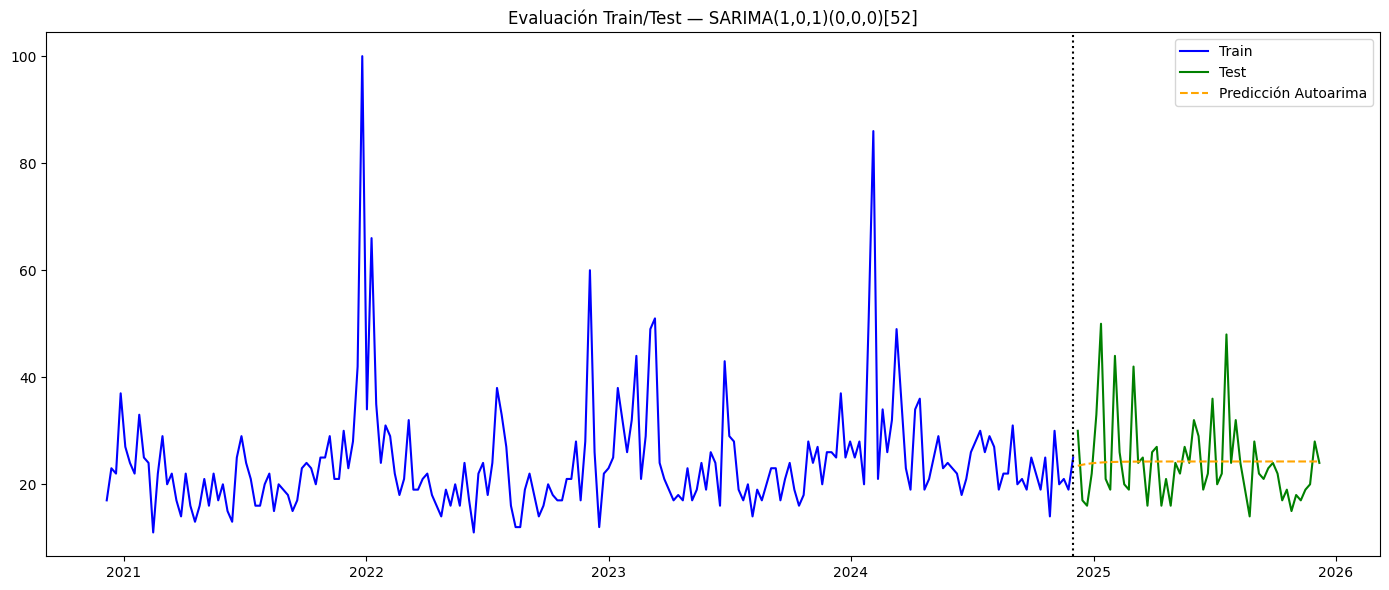

In [39]:
plt.figure(figsize=(14,6))
plt.plot(y_train, label="Train", color="blue")
plt.plot(y_test, label="Test", color="green")
plt.plot(fc_auto, label="Predicción Autoarima",
         linestyle="--", color="orange")

plt.axvline(y_train.index[-1], color="black", linestyle=":")
plt.title("Evaluación Train/Test — SARIMA(1,0,1)(0,0,0)[52]")
plt.legend()
plt.tight_layout()
plt.show()

La evaluación del desempeño se realizó mediante un esquema de entrenamiento y prueba, ajustando los modelos únicamente sobre el conjunto de training y evaluando su capacidad predictiva sobre el conjunto de test. Tanto las métricas de error como la inspección gráfica evidencian diferencias claras en el comportamiento fuera de muestra.

En particular, el modelo SARIMA(1,0,3)×(0,0,2)[52] presenta un desempeño sustancialmente superior, con valores significativamente menores de RMSE y MAE. En contraste, el modelo con diferenciación muestra un deterioro marcado de la capacidad predictiva, reflejado en un aumento considerable de los errores y en una mayor variabilidad de las predicciones respecto de los valores observados.

Estos resultados indican que, bajo el esquema de evaluación considerado, la diferenciación no aporta mejoras en términos de desempeño fuera de muestra y refuerzan la elección del modelo sin diferenciación como la especificación más adecuada desde una perspectiva predictiva, manteniendo al mismo tiempo coherencia con los supuestos de estacionariedad evaluados previamente.

***Temperatura***

In [38]:
fc_auto_temp = model_auto_temp.get_forecast(steps=len(y_test_temp   )).predicted_mean
fc_auto_temp.index = y_test_temp.index

rmse_auto = np.sqrt(mean_squared_error(y_test_temp, fc_auto_temp))
mae_auto  = mean_absolute_error(y_test_temp, fc_auto_temp)

print(f"Autoarima | RMSE: {rmse_auto:.2f} | MAE: {mae_auto:.2f}")

Autoarima | RMSE: 3.16 | MAE: 2.51


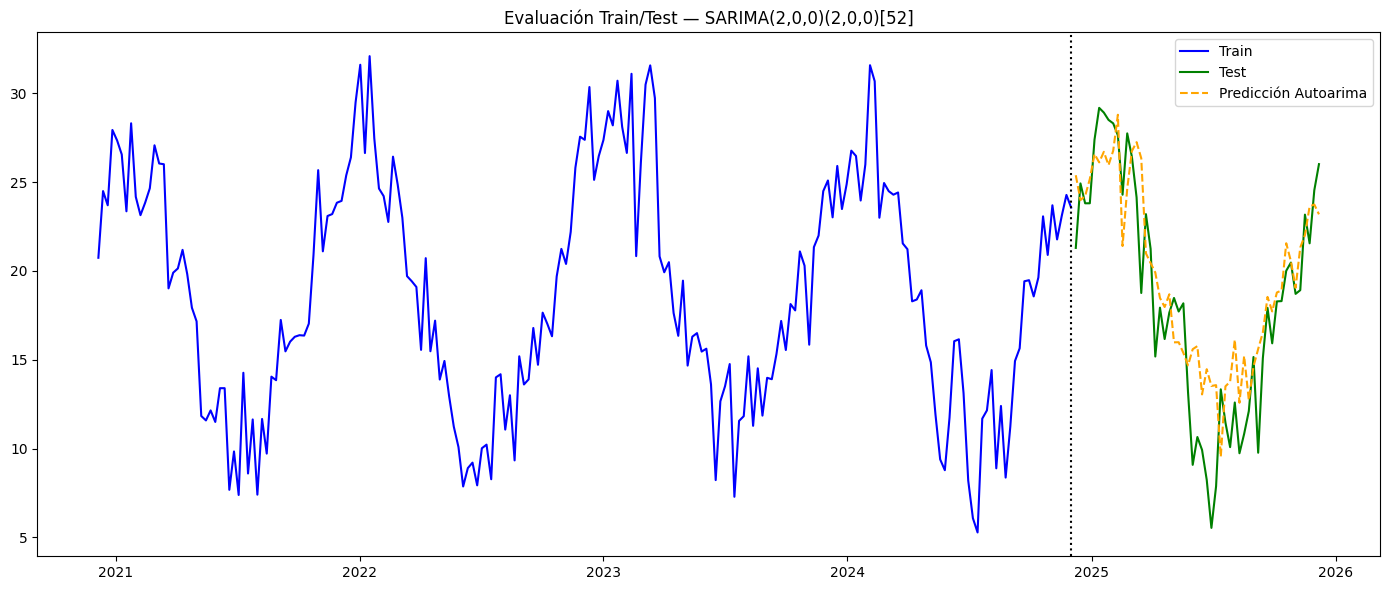

In [39]:
plt.figure(figsize=(14,6))
plt.plot(y_train_temp, label="Train", color="blue")
plt.plot(y_test_temp, label="Test", color="green")
plt.plot(fc_auto_temp, label="Predicción Autoarima",
         linestyle="--", color="orange")

plt.axvline(y_train_temp.index[-1], color="black", linestyle=":")
plt.title("Evaluación Train/Test — SARIMA(2,0,0)(2,0,0)[52]")
plt.legend()
plt.tight_layout()
plt.show()

***Humedad***

In [40]:
fc_auto_hum = model_auto_hum.get_forecast(steps=len(y_test_hum   )).predicted_mean
fc_auto_hum.index = y_test_hum.index

rmse_auto_hum = np.sqrt(mean_squared_error(y_test_hum, fc_auto_hum))
mae_auto_hum  = mean_absolute_error(y_test_hum, fc_auto_hum)

print(f"Autoarima | RMSE: {rmse_auto:.2f} | MAE: {mae_auto:.2f}")

Autoarima | RMSE: 3.16 | MAE: 2.51


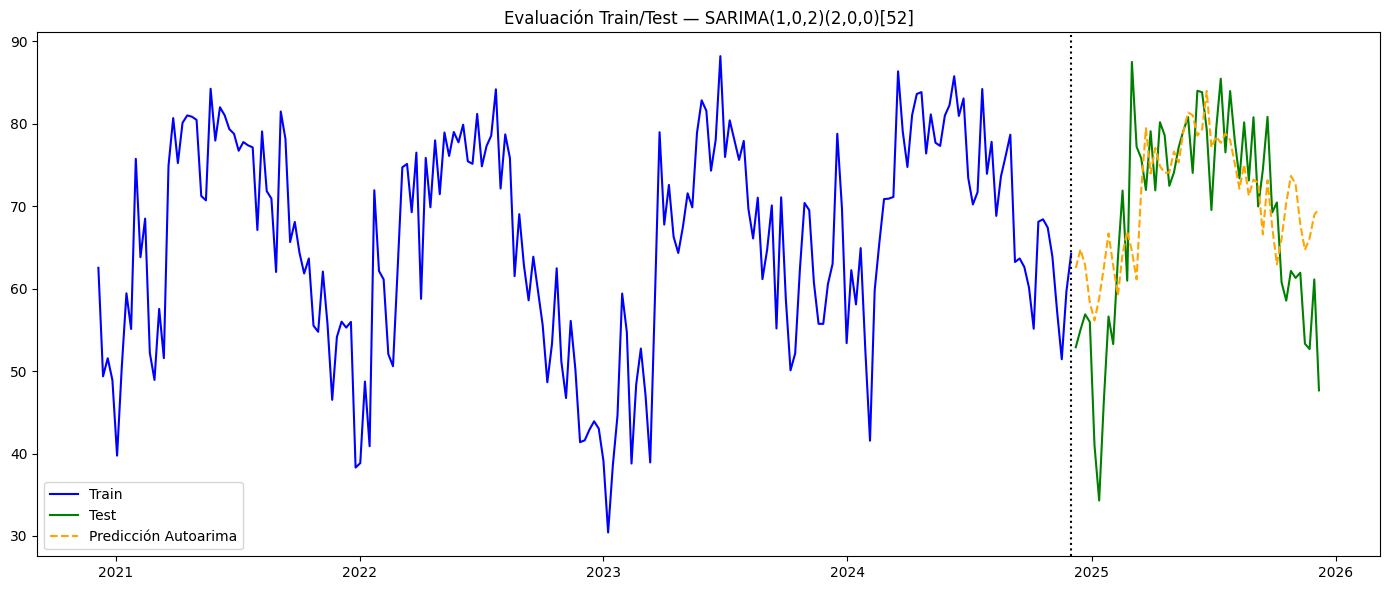

In [41]:
plt.figure(figsize=(14,6))
plt.plot(y_train_hum, label="Train", color="blue")
plt.plot(y_test_hum, label="Test", color="green")
plt.plot(fc_auto_hum, label="Predicción Autoarima",
         linestyle="--", color="orange")

plt.axvline(y_train_hum.index[-1], color="black", linestyle=":")
plt.title("Evaluación Train/Test — SARIMA(1,0,2)(2,0,0)[52]")
plt.legend()
plt.tight_layout()
plt.show()

### 7.2 Evaluación de estabilidad temporal mediante ventanas móviles (Rolling Window)

Con el objetivo de evaluar la estabilidad temporal de los modelos estimados, se implementó un esquema de ventanas móviles (rolling window), reestimando los modelos sobre distintos subconjuntos consecutivos de la serie y evaluando su desempeño predictivo a un horizonte corto. Este enfoque permite analizar la robustez de los modelos frente a cambios temporales en la información disponible y detectar posibles períodos de degradación en la capacidad predictiva.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

y_full = df['Cortes']   # o el nombre real de tu serie
y_full = y_full.asfreq('W').dropna()

window_size = int(len(y_full) * 0.6)
horizons = [1, 2,3]

results = []

for h in horizons:
    rmse_no_list, mae_no_list = [], []
    rmse_diff_list, mae_diff_list = [], []
    rmse_auto_list, mae_auto_list = [], []

    for start in range(0, len(y_full) - window_size - h):
        train_rw = y_full.iloc[start:start + window_size]
        test_rw  = y_full.iloc[start + window_size:start + window_size + h]

        # --- SARIMA sin diferenciación
        model_no = SARIMAX(
            train_rw,
            order=(1,0,3),
            seasonal_order=(0,0,2,52),
            trend="c",
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)

        fc_no = model_no.get_forecast(steps=h).predicted_mean
        rmse_no_list.append(np.sqrt(mean_squared_error(test_rw, fc_no)))
        mae_no_list.append(mean_absolute_error(test_rw, fc_no))

        # --- SARIMA con diferenciación
        model_diff = SARIMAX(
            train_rw,
            order=(0,0,0),
            seasonal_order=(1,1,0,52),
            trend="c",
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)

        fc_diff = model_diff.get_forecast(steps=h).predicted_mean
        rmse_diff_list.append(np.sqrt(mean_squared_error(test_rw, fc_diff)))
        mae_diff_list.append(mean_absolute_error(test_rw, fc_diff))

        # --- AutoARIMA (ARIMA(1,0,1))
        model_auto = SARIMAX(
            train_rw,
            order=(1,0,1),
            seasonal_order=(0,0,0,52),
            trend="c",
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)

        fc_auto = model_auto.get_forecast(steps=h).predicted_mean
        rmse_auto_list.append(np.sqrt(mean_squared_error(test_rw, fc_auto)))
        mae_auto_list.append(mean_absolute_error(test_rw, fc_auto))

    results.append({
        "Horizonte": h,
        "RMSE_SARIMA_no": np.mean(rmse_no_list),
        "MAE_SARIMA_no": np.mean(mae_no_list),
        "RMSE_SARIMA_diff": np.mean(rmse_diff_list),
        "MAE_SARIMA_diff": np.mean(mae_diff_list),
        "RMSE_AutoARIMA": np.mean(rmse_auto_list),
        "MAE_AutoARIMA": np.mean(mae_auto_list)
    })


El gráfico de RMSE a lo largo de las ventanas permite visualizar tendencias en el error, períodos de alta variabilidad y comparar el desempeño relativo de los modelos en cada ventana temporal.

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(rmse_no_list, label="RMSE SARIMA sin diferenciación")
plt.plot(rmse_diff_list, label="RMSE SARIMA con diferenciación")
plt.plot(rmse_auto_list, label="RMSE AUTOARIMA  ")
plt.legend()
plt.title("Rolling Window — RMSE a horizonte corto")
plt.tight_layout()
plt.show()


### 7.3 Evaluación del aporte de variables exógenas (SARIMAX)

Con el objetivo de evaluar el aporte marginal de información exógena, se estimaron extensiones SARIMAX de los modelos considerados, incorporando temperatura y humedad como variables explicativas. La comparación se realizó bajo el mismo esquema de entrenamiento y prueba, utilizando métricas de error fuera de muestra. Este análisis permite contrastar si la inclusión de variables climáticas mejora la capacidad predictiva del modelo univariado.

In [42]:
X_train = train[['Temp', 'Hum']].asfreq('W').loc[y_train.index]
X_test  = test[['Temp', 'Hum']].asfreq('W').loc[y_test.index]


#### SARIMAX A PARTIR DEL AUTOARIMA

In [44]:
model_no_exog = SARIMAX(
    y_train,
    exog=X_train,
    order=(1,0,1),
    seasonal_order=(0,0,0,52),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

fc_no_exog = model_no_exog.get_forecast(
    steps=len(y_test),
    exog=X_test
).predicted_mean

rmse_no_exog = np.sqrt(mean_squared_error(y_test, fc_no_exog))
mae_no_exog  = mean_absolute_error(y_test, fc_no_exog)

# MAPE (evitando división por cero)
denom = np.where(y_test.values == 0, np.nan, y_test.values)
mape_no_exog = np.nanmean(np.abs((y_test.values - fc_no_exog.values) / denom)) * 100

print(
    f"SARIMAX sin diff | "
    f"RMSE: {rmse_no_exog:.2f} | "
    f"MAE: {mae_no_exog:.2f} | "
    f"MAPE: {mape_no_exog:.2f}%"
)


SARIMAX sin diff | RMSE: 8.95 | MAE: 6.99 | MAPE: 29.47%


La incorporación de variables exógenas mediante modelos SARIMAX no produce mejoras en el desempeño predictivo fuera de muestra respecto de las especificaciones univariadas SARIMA. En todos los casos evaluados, la inclusión de temperatura y humedad se asocia a un aumento de los errores de pronóstico, reflejado en valores superiores de RMSE y MAE.

Si bien las pruebas de causalidad de Granger sugieren la existencia de información predictiva de corto plazo contenida en las variables climáticas, dicho aporte no se traduce en una reducción efectiva y estable de los errores fuera de muestra. En particular, el deterioro del desempeño es más pronunciado en el modelo con diferenciación, donde los errores aumentan de manera considerable.

En conjunto, estos resultados refuerzan la caracterización de la serie de cortes de luz como un proceso mayormente autocontenido, cuya dinámica es explicada principalmente por su propia historia, mientras que la información exógena aporta un valor limitado desde una perspectiva predictiva agregada.

## 8. Pronóstico y comparación de escenarios



### Esquema de pronóstico

***Cortes- Google Trends***

Se generan pronósticos a h pasos hacia adelante utilizando ambos modelos candidatos estimados sobre la serie completa disponible. El objetivo es comparar las trayectorias previstas y analizar las diferencias asociadas a la especificación del modelo.

In [48]:
#Reajuste de ambos modelos sobre la serie completa
y_full = df['Cortes'].asfreq('W').dropna()

model_auto_full = SARIMAX(
    y_full,
    order=(1,0,1),
    seasonal_order=(0,0,0,52),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)


In [51]:
#Generación de pronósticos
h = 6  # horizonte de pronóstico (UN MES)

fc_auto = model_auto_full.get_forecast(steps=h)


fc_auto_mean = fc_auto.predicted_mean

ci_auto = fc_auto.conf_int()


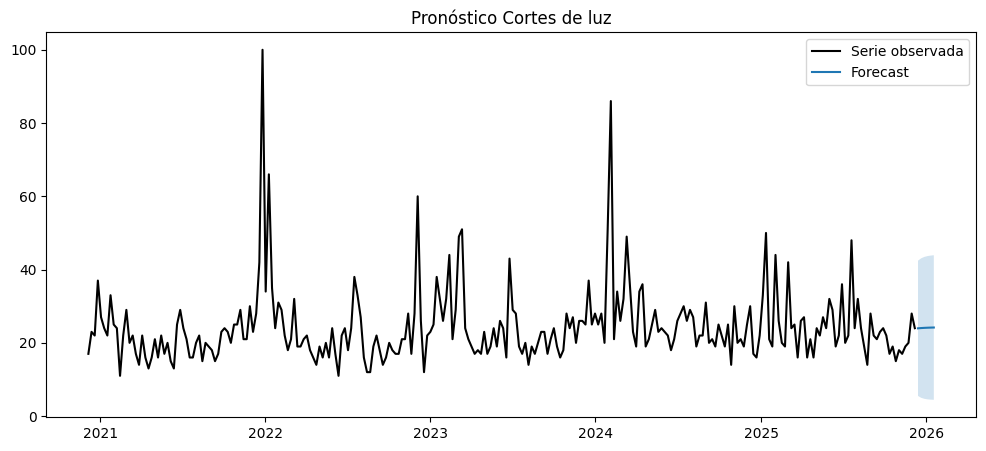

In [52]:
#Gráfico comparativo de pronósticos
plt.figure(figsize=(12,5))

# Serie histórica
plt.plot(y_full.index, y_full, label="Serie observada", color="black")

# Pronósticos
plt.plot(fc_auto_mean.index, fc_auto_mean, label="Forecast")

# Intervalos de confianza
plt.fill_between(
    ci_auto.index,
    ci_auto.iloc[:,0],
    ci_auto.iloc[:,1],
    alpha=0.2
)


plt.title("Pronóstico Cortes de luz")
plt.legend()
plt.show()


Los pronósticos se obtienen reestimando ambos modelos sobre la serie completa, con el objetivo de analizar el comportamiento esperado del proceso a un horizonte medio, más que de identificar una predicción puntual óptima. En este contexto, el pronóstico refleja directamente los supuestos estructurales del modelo utilizado y la forma en que éste representa la dinámica temporal de la serie.

Los modelos SARIMA sin diferenciación describen el proceso como estacionario en niveles, por lo que los pronósticos tienden a estabilizarse alrededor de un valor medio, con una incertidumbre que crece de manera gradual al aumentar el horizonte. Esta propiedad es consistente con procesos con memoria corta, donde los efectos de los shocks se disipan con relativa rapidez.

En cambio, los modelos con diferenciación estacional asumen la presencia de un componente no estacionario asociado a la estacionalidad. En este caso, el pronóstico se construye a partir de la acumulación de variaciones estacionales, lo que suele generar trayectorias más sensibles a la información reciente y una mayor expansión de los intervalos de confianza a horizontes más largos.

De este modo, las diferencias entre los pronósticos no deben interpretarse como un criterio automático de selección, sino como el resultado de supuestos teóricos distintos sobre la naturaleza del proceso generador de datos y su persistencia en el tiempo.

***Temperatura***

In [42]:
#Reajuste de ambos modelos sobre la serie completa
y_full_temp = df['Temp'].asfreq('W').dropna()

model_auto_full_temp = SARIMAX(
    y_full_temp,
    order=(2,0,0),
    seasonal_order=(2,0,0,52),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

In [43]:
#Generación de pronósticos
h = 6  # horizonte de pronóstico (UN MES)

fc_auto_temp = model_auto_full_temp.get_forecast(steps=h)


fc_auto_mean = fc_auto_temp.predicted_mean

ci_auto = fc_auto_temp.conf_int()

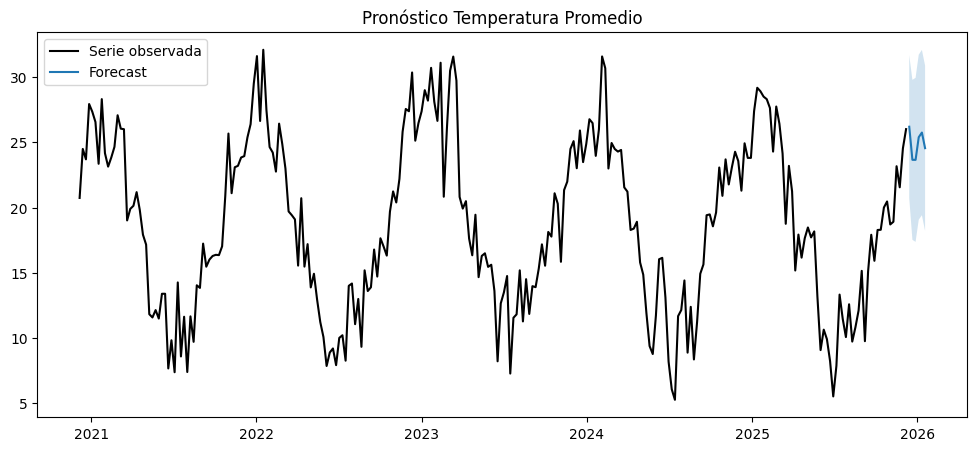

In [44]:
#Gráfico comparativo de pronósticos
plt.figure(figsize=(12,5))

# Serie histórica
plt.plot(y_full_temp.index, y_full_temp, label="Serie observada", color="black")

# Pronósticos
plt.plot(fc_auto_mean.index, fc_auto_mean, label="Forecast")

# Intervalos de confianza
plt.fill_between(
    ci_auto.index,
    ci_auto.iloc[:,0],
    ci_auto.iloc[:,1],
    alpha=0.2
)


plt.title("Pronóstico Temperatura Promedio")
plt.legend()
plt.show()

***Humedad***

In [45]:
#Reajuste de ambos modelos sobre la serie completa
y_full_hum = df['Hum'].asfreq('W').dropna()

model_auto_full_hum = SARIMAX(
    y_full_hum,
    order=(1,0,2),
    seasonal_order=(2,0,0,52),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

In [46]:
#Generación de pronósticos
h = 6  # horizonte de pronóstico (UN MES)

fc_auto_hum = model_auto_full_hum.get_forecast(steps=h)


fc_auto_mean = fc_auto_hum.predicted_mean

ci_auto = fc_auto_hum.conf_int()

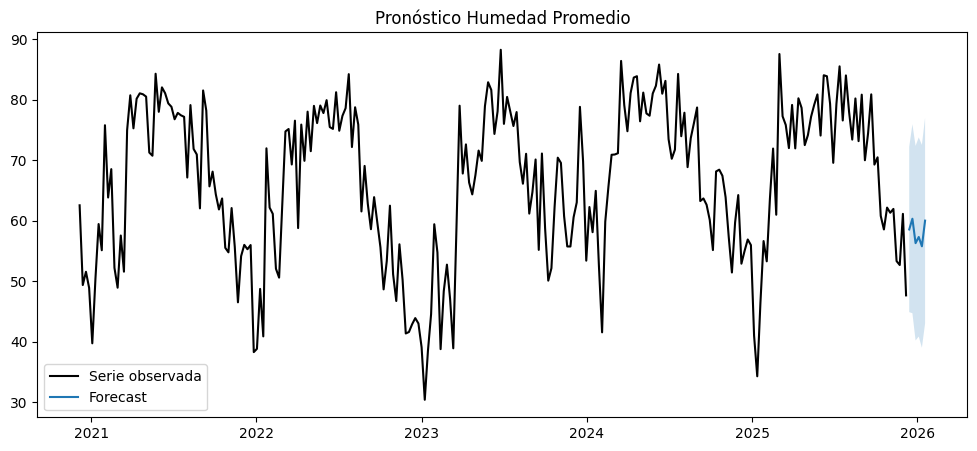

In [47]:
#Gráfico comparativo de pronósticos
plt.figure(figsize=(12,5))

# Serie histórica
plt.plot(y_full_hum.index, y_full_hum, label="Serie observada", color="black")

# Pronósticos
plt.plot(fc_auto_mean.index, fc_auto_mean, label="Forecast")

# Intervalos de confianza
plt.fill_between(
    ci_auto.index,
    ci_auto.iloc[:,0],
    ci_auto.iloc[:,1],
    alpha=0.2
)


plt.title("Pronóstico Humedad Promedio")
plt.legend()
plt.show()

## 9. VAR

Se estimó un modelo de Vectores Autorregresivos (VAR) con el objetivo de analizar la dinámica conjunta entre la serie de Cortes de luz, Temperatura y Humedad, incorporando explícitamente posibles interacciones dinámicas entre las variables. A diferencia del enfoque univariado SARIMA, el modelo VAR permite tratar a todas las series como endógenas dentro de un sistema dinámico común.

Dado que las tres series resultaron estacionarias en niveles según el test ADF, el modelo fue estimado sin aplicar diferenciaciones adicionales. El número de rezagos se seleccionó mediante criterios de información, priorizando un compromiso entre ajuste y parsimonia, lo que condujo a la estimación de un VAR de bajo orden.

Los resultados indican que la dinámica de la serie de cortes de luz está explicada principalmente por su propia historia, mientras que los rezagos de temperatura y humedad no resultan estadísticamente significativos en su ecuación. En contraste, las ecuaciones correspondientes a temperatura y humedad muestran una fuerte persistencia temporal y una relación dinámica consistente con su interpretación física. En conjunto, el VAR sugiere que, dentro del sistema multivariado considerado, no se observa una transmisión dinámica relevante desde las variables climáticas hacia la serie de cortes en el corto plazo.

Este resultado complementa el análisis univariado previo, reforzando la idea de que la serie de cortes presenta una dinámica predominantemente autocontenida, mientras que la inclusión de variables exógenas aporta información limitada desde una perspectiva estrictamente predictiva.

In [49]:
import pandas as pd
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller



ADF en niveles
Cortes   | ADF =  -6.642 | p-value = 0.0000
Temp     | ADF =  -7.024 | p-value = 0.0000
Hum      | ADF =  -4.988 | p-value = 0.0000
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        12.70       12.74   3.279e+05       12.72
1        10.49      10.65*   3.583e+04       10.55
2       10.36*       10.66  3.168e+04*      10.48*
3        10.39       10.81   3.245e+04       10.56
4        10.42       10.96   3.340e+04       10.64
5        10.42       11.09   3.350e+04       10.69
6        10.45       11.25   3.461e+04       10.77
7        10.51       11.43   3.674e+04       10.88
8        10.49       11.54   3.597e+04       10.91
9        10.52       11.69   3.707e+04       10.99
10       10.53       11.83   3.739e+04       11.05
--------------------------------------------------
  Summary of Regression Results   
Model:                         VAR
Method:           

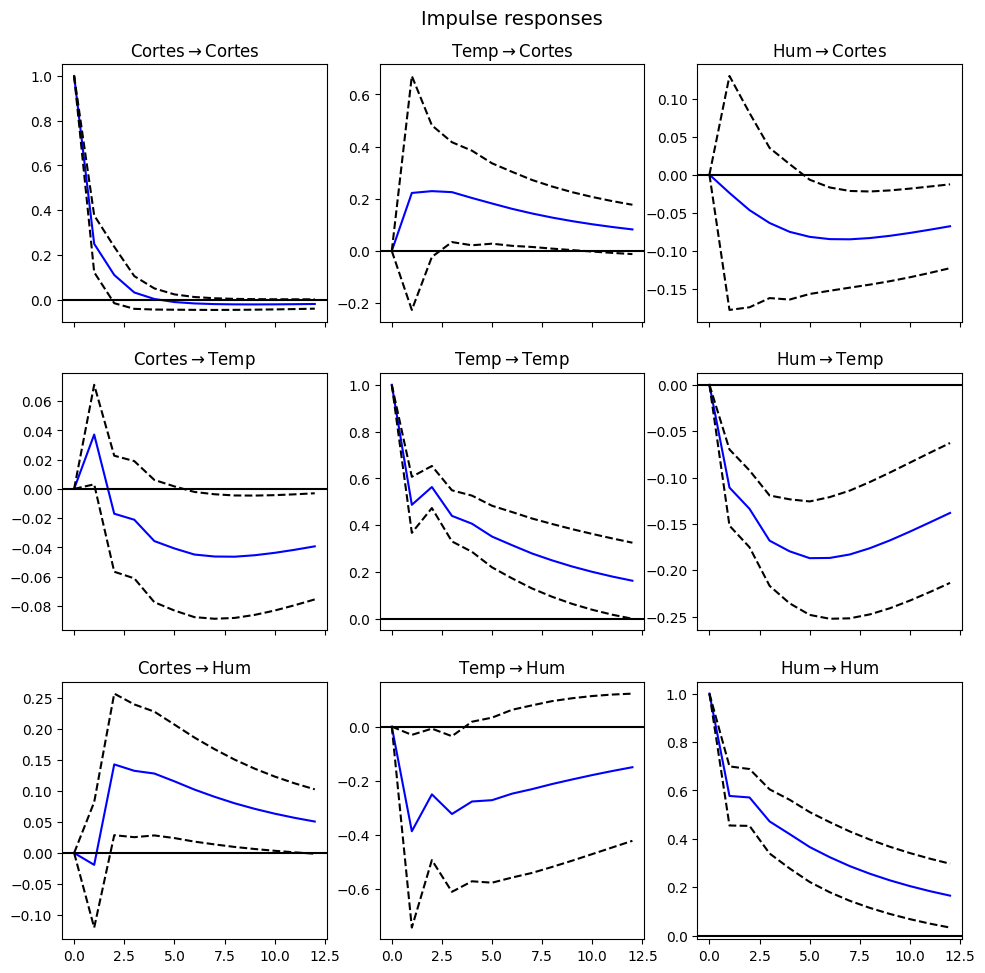

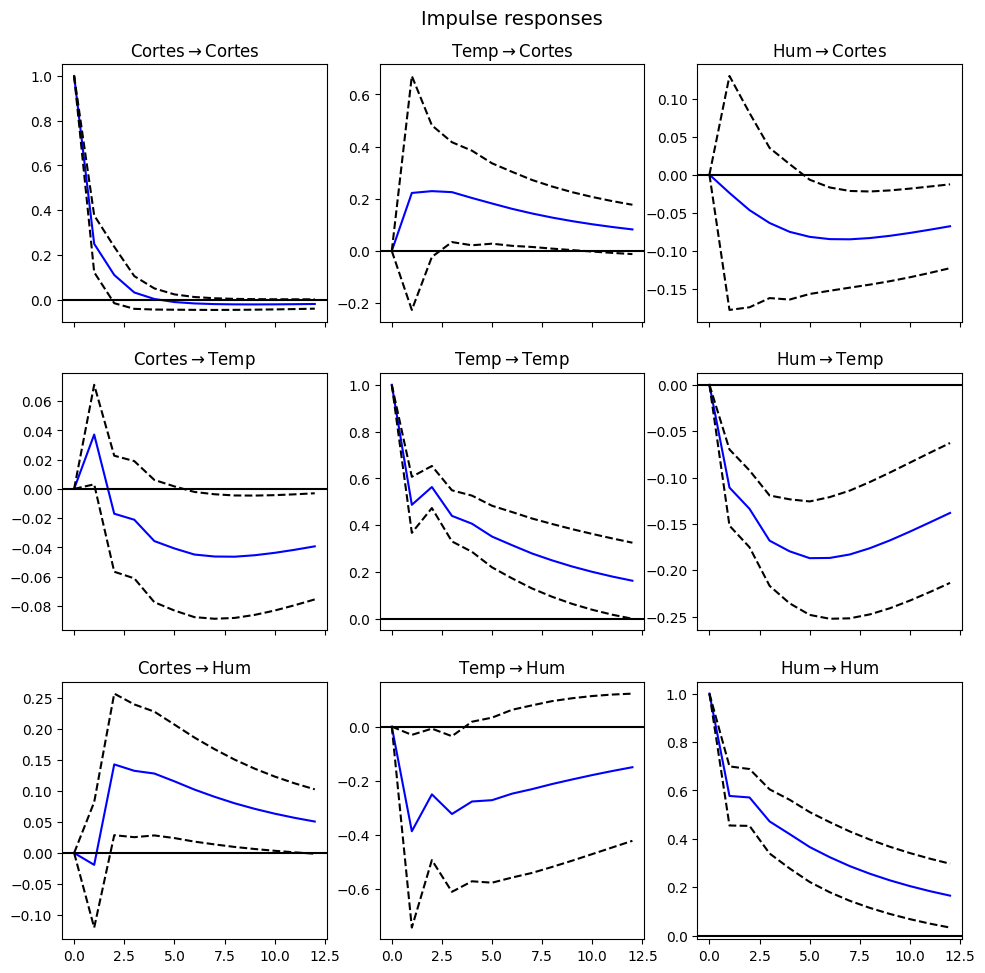

In [50]:
# =========================
# 1. Dataset multivariado
# =========================
data = df[['Cortes', 'Temp', 'Hum']].asfreq('W').dropna()

# =========================
# 2. Chequeo rápido de estacionariedad (ADF)
# =========================
def adf_report(series, name):
    res = adfuller(series, autolag="AIC")
    print(f"{name:8s} | ADF = {res[0]:7.3f} | p-value = {res[1]:.4f}")

print("ADF en niveles")
for col in data.columns:
    adf_report(data[col], col)

# =========================
# 3. Selección de rezagos
# =========================
var_model = VAR(data)
lag_selection = var_model.select_order(maxlags=10)
print(lag_selection.summary())

# Elegir rezago (ejemplo: 2)
p = 2

# =========================
# 4. Estimación VAR
# =========================
var_res = var_model.fit(p)
print(var_res.summary())

# =========================
# 5. Estabilidad del VAR
# =========================
print("VAR estable:", var_res.is_stable())

# =========================
# 6. Impulse Response Functions (IRF)
# =========================
irf = var_res.irf(12)  # horizonte de 12 semanas
irf.plot(orth=False)


In [51]:
# =========================
# Causalidad de Granger
# =========================
from statsmodels.tsa.stattools import grangercausalitytests

max_lag = 2  # consistente con el VAR(2)

print("Temp → Cortes")
grangercausalitytests(
    data[['Cortes', 'Temp']], 
    maxlag=max_lag, 
    verbose=True
)

print("\nHum → Cortes")
grangercausalitytests(
    data[['Cortes', 'Hum']], 
    maxlag=max_lag, 
    verbose=True
)


Temp → Cortes

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=11.3356 , p=0.0009  , df_denom=258, df_num=1
ssr based chi2 test:   chi2=11.4674 , p=0.0007  , df=1
likelihood ratio test: chi2=11.2226 , p=0.0008  , df=1
parameter F test:         F=11.3356 , p=0.0009  , df_denom=258, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=4.6997  , p=0.0099  , df_denom=255, df_num=2
ssr based chi2 test:   chi2=9.5838  , p=0.0083  , df=2
likelihood ratio test: chi2=9.4114  , p=0.0090  , df=2
parameter F test:         F=4.6997  , p=0.0099  , df_denom=255, df_num=2

Hum → Cortes

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=5.9320  , p=0.0155  , df_denom=258, df_num=1
ssr based chi2 test:   chi2=6.0010  , p=0.0143  , df=1
likelihood ratio test: chi2=5.9330  , p=0.0149  , df=1
parameter F test:         F=5.9320  , p=0.0155  , df_denom=258, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:   

{np.int64(1): ({'ssr_ftest': (np.float64(5.9320202287627755),
    np.float64(0.015545935072240046),
    np.float64(258.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(6.000997208166993),
    np.float64(0.014297794729373111),
    np.int64(1)),
   'lrtest': (np.float64(5.933048328416135),
    np.float64(0.014859515698065448),
    np.int64(1)),
   'params_ftest': (np.float64(5.932020228762787),
    np.float64(0.015545935072240046),
    np.float64(258.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(2.954197936443112),
    np.float64(0.05390710839115523),
    np.float64(255.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(6.024246772354582),
    np.float64(0.049187124534909636),
    np.int64(2)),
   'lrtest': (np.float64(5.9555149917878225),
    np.float64(0.05090686481304834),
    np.int64(2)),
   'params_ftest': (np.float64(2.954197936443235),
    np.float64(0.05390710839114906),
    np.float64(255.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],

Las pruebas de causalidad de Granger indican que la temperatura presenta evidencia estadísticamente significativa de causalidad de Granger sobre la serie de cortes de luz, principalmente a rezagos cortos. En el caso de la humedad, los resultados sugieren una relación más débil y sensible al número de rezagos considerados.

No obstante, estos resultados deben interpretarse con cautela, dado que la causalidad de Granger refiere exclusivamente a contenido predictivo y no implica una relación causal estructural. En línea con este punto, las funciones impulso–respuesta muestran que los shocks en las variables climáticas generan respuestas de baja magnitud y escasa persistencia en la serie de cortes.

En conjunto, el análisis VAR sugiere que, si bien las variables climáticas aportan información predictiva marginal en el muy corto plazo, la dinámica de la serie de cortes de luz se encuentra dominada por su propia estructura temporal. Las interacciones dinámicas detectadas no se traducen en efectos persistentes, lo que refuerza la caracterización de los cortes como un proceso mayormente autocontenido.

La evidencia multivariada es consistente con los resultados obtenidos mediante modelos SARIMA. Mientras que el enfoque VAR permite identificar relaciones predictivas de corto plazo entre las variables, los modelos univariados capturan adecuadamente la dinámica dominante de la serie de cortes. En este sentido, la inclusión de variables climáticas no altera sustancialmente las conclusiones sobre el comportamiento temporal del proceso, aunque aporta información adicional en horizontes muy cortos.

# =========================
# Pronósticos VAR
# =========================

In [55]:
# =========================
# PRONÓSTICO VAR FINAL
# =========================

# Horizonte de pronóstico (ejemplo: 6 semanas)
h = 6

# Reestimar VAR con toda la muestra disponible
var_model_full = VAR(data)
var_res_full = var_model_full.fit(p)

# Generar pronóstico
var_forecast = var_res_full.forecast(
    data.values[-p:], 
    steps=h
)

# DataFrame de pronósticos
var_forecast_df = pd.DataFrame(
    var_forecast,
    columns=['Cortes', 'Temp', 'Hum'],
    index=pd.date_range(
        start=data.index[-1] + pd.Timedelta(weeks=1),
        periods=h,
        freq='W'
    )
)

print("PRONÓSTICO VAR (6 semanas):")
print(var_forecast_df.round(2))


PRONÓSTICO VAR (6 semanas):
            Cortes   Temp    Hum
2025-12-14   26.79  25.84  53.37
2025-12-21   27.27  26.03  53.60
2025-12-28   27.52  25.85  55.22
2026-01-04   27.53  25.62  56.38
2026-01-11   27.45  25.29  57.47
2026-01-18   27.31  24.93  58.41


In [53]:
# =========================
# PRONÓSTICO VAR + IC
# =========================

fc_mean, fc_lower, fc_upper = var_res_full.forecast_interval(
    data.values[-p:], 
    steps=h,
    alpha=0.05
)

var_forecast_ic = pd.DataFrame(
    fc_mean,
    columns=['Cortes', 'Temp', 'Hum'],
    index=var_forecast_df.index
)

var_lower = pd.DataFrame(fc_lower, columns=['Cortes', 'Temp', 'Hum'], index=var_forecast_df.index)
var_upper = pd.DataFrame(fc_upper, columns=['Cortes', 'Temp', 'Hum'], index=var_forecast_df.index)

print("Pronóstico VAR con IC:")
print(var_forecast_ic.round(2))


Pronóstico VAR con IC:
            Cortes   Temp    Hum
2025-12-14   26.79  25.84  53.37
2025-12-21   27.27  26.03  53.60
2025-12-28   27.52  25.85  55.22
2026-01-04   27.53  25.62  56.38
2026-01-11   27.45  25.29  57.47
2026-01-18   27.31  24.93  58.41


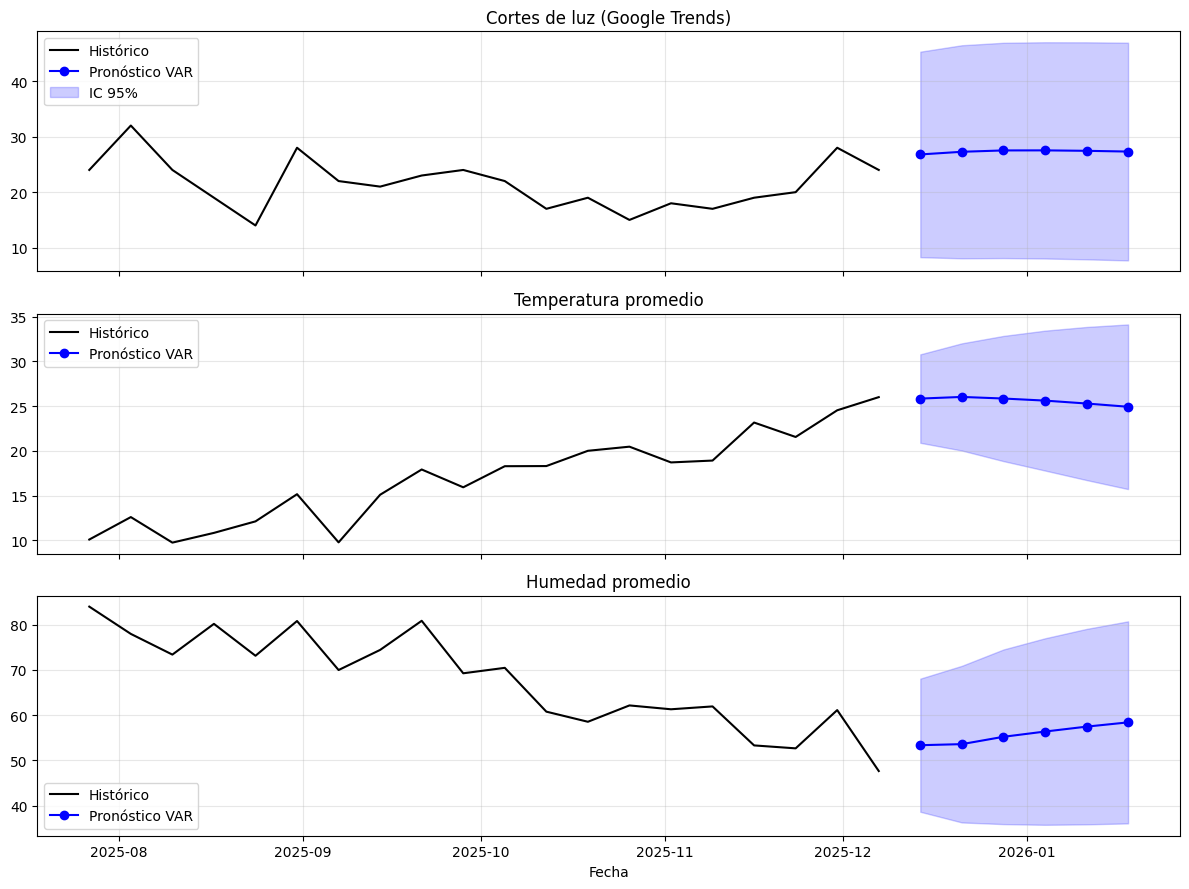

In [54]:
# =========================
# GRÁFICO PRONÓSTICO VAR
# =========================

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

variables = ['Cortes', 'Temp', 'Hum']
titles = ['Cortes de luz (Google Trends)', 'Temperatura promedio', 'Humedad promedio']

for i, var in enumerate(variables):
    axes[i].plot(data.index[-20:], data[var].iloc[-20:], 
                 label='Histórico', color='black')
    
    axes[i].plot(var_forecast_df.index, var_forecast_df[var], 
                 label='Pronóstico VAR', color='blue', marker='o')
    
    axes[i].fill_between(
        var_forecast_df.index,
        var_lower[var],
        var_upper[var],
        color='blue',
        alpha=0.2,
        label='IC 95%' if i == 0 else None
    )
    
    axes[i].set_title(titles[i])
    axes[i].legend()
    axes[i].grid(alpha=0.3)

axes[-1].set_xlabel('Fecha')
plt.tight_layout()
plt.show()
